# Notebook 04 — Эксперимент 2: Профиль доходности

## Исследовательский вопрос
**«Куда идёт акция прямо сейчас и насколько эффективно
она вознаграждает за риск?»**

## Методологическое обоснование горизонта
Метрики доходности по своей природе **режимно-зависимы**:
моментум-эффект работает на горизонте 6–12 месяцев
(Jegadeesh & Titman, 1993; Moskowitz et al., 2012).
Использование 5-летнего среднего усредняло бы сигнал
из принципиально разных рыночных режимов.

Поэтому **все метрики рассчитываются за последний год**
(2024-01-01 → 2024-12-31).

## Анализ стабильности
Проверяем кластеры на трёх независимых годах:
2022, 2023, 2024 — каждый раз пересчитываем метрики
за этот год. Это соответствует годовому горизонту
моментума и обеспечивает независимость подпериодов.

## Метрики (5 показателей)
| Метрика | Что измеряет |
|---|---|
| sharpe | Риск-скорректированная доходность vs безрисковая ставка |
| info_ratio | Доходность сверх S&P 500 / Tracking Error |
| mom_1m | Краткосрочный импульс (последние 21 день) |
| mom_12m | Годовой импульс (последние 252 дня) |
| win_rate | Доля дней с положительной доходностью |

## 1. Импорты и загрузка

In [69]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'font.size': 10,
})

# ── Загрузка данных ──────────────────────────────────────────────────────────
# Сырые данные (нужны для расчёта метрик по годам)
prices         = pd.read_parquet('data/prices.parquet')
simple_returns = pd.read_parquet('data/simple_returns.parquet')
sp500_ret      = pd.read_parquet('data/sp500_index.parquet')['sp500']

# Метаданные
meta     = pd.read_csv('data/sp500_meta.csv', index_col='ticker')
res_exp1 = pd.read_parquet('data/results_exp1.parquet')

with open('data/feature_groups.json') as f:
    FEATURE_GROUPS = json.load(f)

FEATURES  = FEATURE_GROUPS['return']
LABELS    = {
    'sharpe'    : 'Коэф. Шарпа',
    'mom_1m'    : 'Моментум 1М',
    'mom_12m'   : 'Моментум 12М',
    'win_rate'  : 'Win Rate',
}
RISK_FREE   = 0.04 / 252
EXP_NAME    = 'Эксперимент 2: Профиль доходности (2024)'
SAVE_PREFIX = 'plots/04_exp2'

# ── Период основной кластеризации — последний год ────────────────────────────
MAIN_START = '2024-01-01'
MAIN_END   = '2024-12-31'

print(f"Период основной кластеризации: {MAIN_START} → {MAIN_END}")
print(f"Метрики: {FEATURES}")
print(f"Сырые данные: {simple_returns.index[0].date()} → "
      f"{simple_returns.index[-1].date()}")

Период основной кластеризации: 2024-01-01 → 2024-12-31
Метрики: ['sharpe', 'mom_1m', 'mom_12m', 'win_rate']
Сырые данные: 2019-03-21 → 2024-12-30


## 2. Функция расчёта метрик за произвольный год

In [70]:
def compute_return_metrics(simple_ret, price, mkt, rf,
                           prices_full=None, ticker=None):
    mkt_aligned = mkt.reindex(simple_ret.index).dropna()
    s_a         = simple_ret.reindex(mkt_aligned.index)

    excess   = simple_ret - rf
    sigma    = excess.std()
    sharpe   = float(excess.mean()/sigma*np.sqrt(252)) \
               if sigma > 1e-10 else np.nan

    active   = s_a - mkt_aligned
    te       = active.std()
    

    m1m      = float(price.iloc[-1]/price.iloc[-22]-1) \
               if len(price) >= 22 else np.nan

    # mom_12m — берём из полного ряда цен чтобы иметь 252 дня
    if prices_full is not None and ticker is not None:
        p_full = prices_full[ticker].dropna()
        m12m   = float(p_full.iloc[-1]/p_full.iloc[-253]-1) \
                 if len(p_full) >= 253 else np.nan
    else:
        m12m   = float(price.iloc[-1]/price.iloc[-252]-1) \
                 if len(price) >= 252 else np.nan

    win_rate = float((simple_ret > 0).mean())
    return [sharpe, m1m, m12m, win_rate]


def build_features_for_period(start, end, min_days=100):
    tickers = prices.columns.tolist()
    recs    = []
    for ticker in tickers:
        try:
            s  = simple_returns[ticker].loc[start:end].dropna()
            p  = prices[ticker].loc[start:end].dropna()
            sp = sp500_ret.loc[start:end]
            if len(s) < min_days:
                continue
            # Передаём полный ряд цен для расчёта mom_12m
            feats = compute_return_metrics(
                s, p, sp, RISK_FREE,
                prices_full=prices, ticker=ticker
            )
            if not np.isnan(feats[0]) and not np.isnan(feats[1]):
                recs.append({'ticker': ticker,
                             **dict(zip(FEATURES, feats))})
        except Exception:
            pass
    if not recs:
        return pd.DataFrame()
    return pd.DataFrame(recs).set_index('ticker')

In [71]:
# Перезапусти ячейку с определением функций сначала!
# Потом запусти это:

ticker = 'AAPL'
s  = simple_returns[ticker].loc['2024-01-01':'2024-12-31'].dropna()
p  = prices[ticker].loc['2024-01-01':'2024-12-31'].dropna()
sp = sp500_ret.loc['2024-01-01':'2024-12-31']

feats = compute_return_metrics(
    s, p, sp, RISK_FREE,
    prices_full=prices, ticker=ticker
)
print(f"Метрики AAPL: {[round(f,3) for f in feats]}")
print(f"mom_12m = {feats[3]}")

Метрики AAPL: [1.152, 0.074, 0.309, 0.566]
mom_12m = 0.5657370517928287


In [72]:
p_full = prices['AAPL'].dropna()
print(f"Полный ряд: {len(p_full)} дней")
print(f"Последняя дата: {p_full.index[-1].date()}")
print(f"len >= 253: {len(p_full) >= 253}")

Полный ряд: 1509 дней
Последняя дата: 2024-12-30
len >= 253: True


## 3. Основная кластеризация — данные 2024 года

In [73]:
print(f"Рассчитываем метрики за {MAIN_START} → {MAIN_END}...")
X_raw = build_features_for_period(MAIN_START, MAIN_END)

# Добавляем метаданные
X_raw = X_raw.join(meta[['sector', 'name']], how='left')

print(f"Акций с полными метриками: {len(X_raw)}")
print(f"\nОписательная статистика (2024):")
X_raw[FEATURES].describe().round(3)

Рассчитываем метрики за 2024-01-01 → 2024-12-31...
Акций с полными метриками: 481

Описательная статистика (2024):


,sharpe,mom_1m,mom_12m,win_rate
count,481.000,481.000,481.000,481.000
mean,0.505,-0.060,0.179,0.524
std,0.905,0.069,0.356,0.034
min,-2.183,-0.323,-0.601,0.418
25%,-0.129,-0.098,-0.032,0.502
50%,0.526,-0.068,0.134,0.522
75%,1.134,-0.031,0.333,0.546
max,3.043,0.479,2.834,0.622


## 4. Распределения метрик

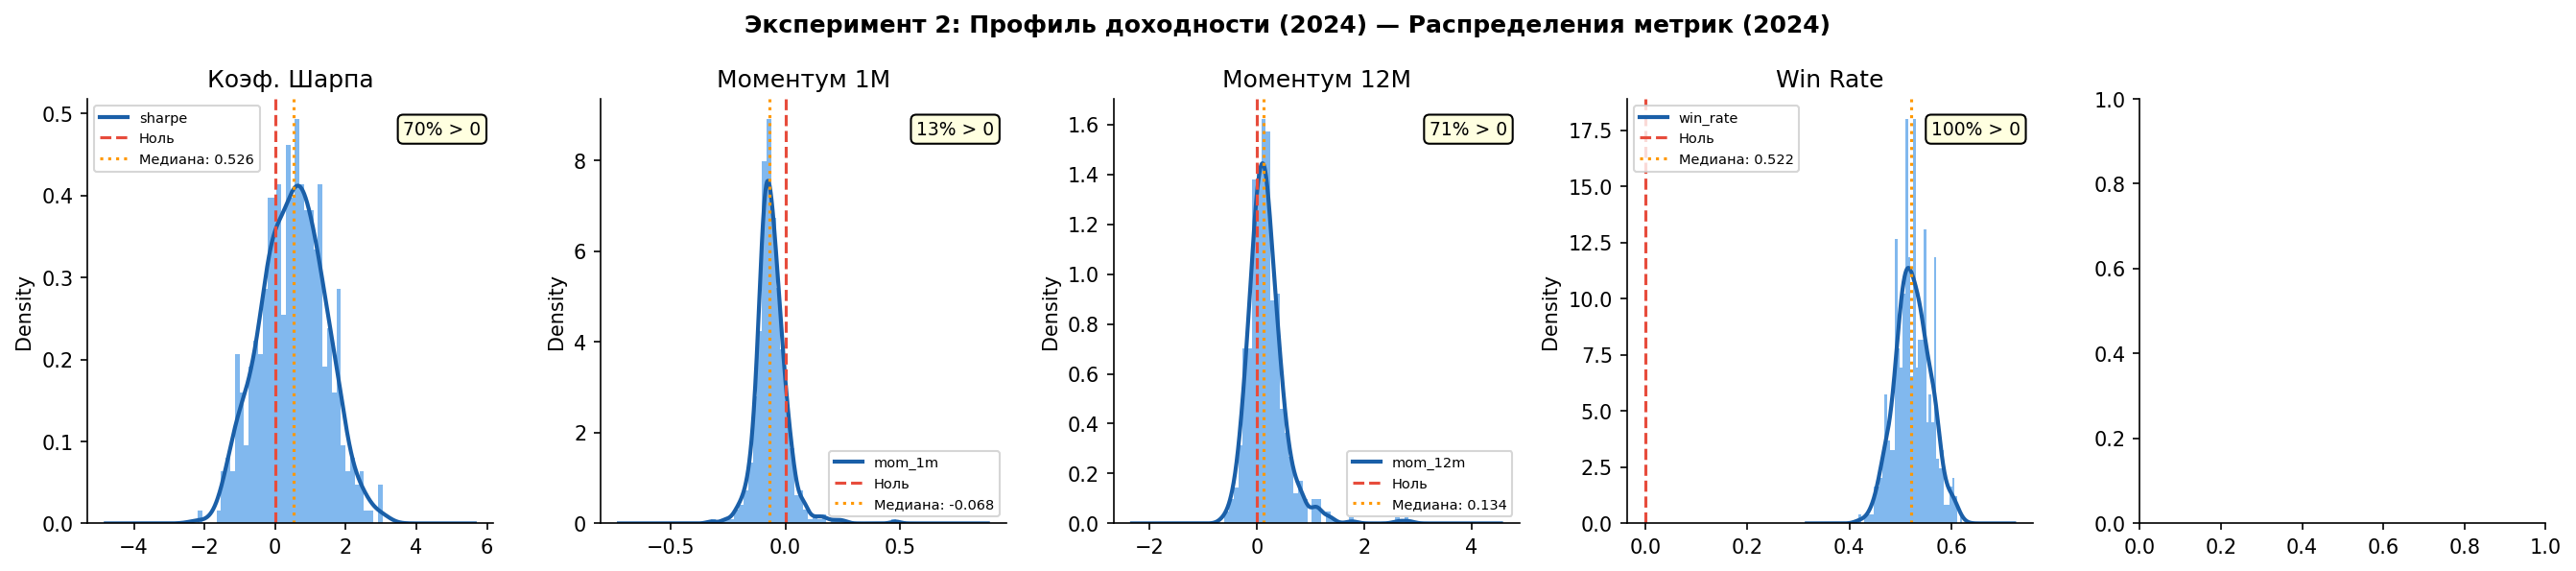

Ключевые наблюдения (2024):
  Коэф. Шарпа       : медиана=0.526, >0%: 70%
  Моментум 1М       : медиана=-0.068, >0%: 13%
  Моментум 12М      : медиана=0.134, >0%: 71%
  Win Rate          : медиана=0.522, >0%: 100%


In [74]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle(f'{EXP_NAME} — Распределения метрик (2024)',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes, FEATURES):
    data = X_raw[feat].dropna()
    ax.hist(data, bins=40, color='#4C9BE8', alpha=0.7, density=True)
    data.plot.kde(ax=ax, color='#1a5fa8', linewidth=2)
    ax.axvline(0, color='#e74c3c', linestyle='--', linewidth=1.5,
               label='Ноль')
    ax.axvline(data.median(), color='#FF9800', linestyle=':',
               linewidth=1.5,
               label=f'Медиана: {data.median():.3f}')
    pct_pos = (data > 0).mean() * 100
    ax.text(0.97, 0.95, f'{pct_pos:.0f}% > 0',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightyellow'))
    ax.set_title(LABELS[feat])
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Ключевые наблюдения (2024):")
for feat in FEATURES:
    d = X_raw[feat]
    print(f"  {LABELS[feat]:18s}: "
          f"медиана={d.median():.3f}, "
          f">{0:.0f}%: {(d>0).mean()*100:.0f}%")

## 5. Масштабирование и выбор K

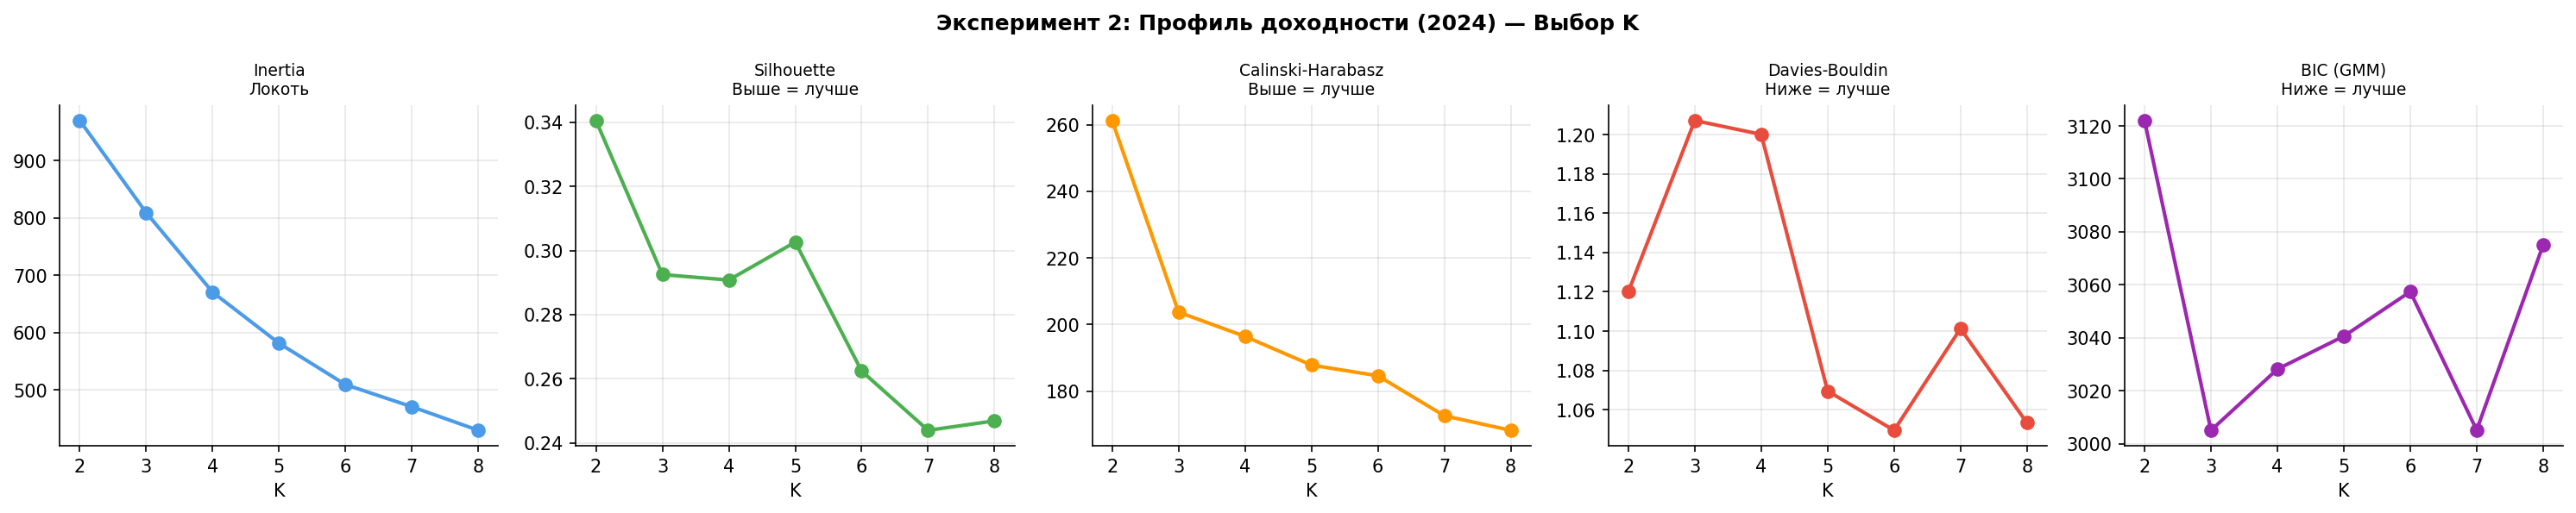

   Inertia  Silhouette     CH     DB  BIC(GMM)
K                                             
2    970.1       0.341  261.2  1.120    3122.0
3    809.3       0.292  203.7  1.207    3005.0
4    670.6       0.291  196.5  1.200    3028.1
5    581.4       0.303  187.8  1.070    3040.6
6    509.3       0.262  184.7  1.050    3057.4
7    470.6       0.244  172.6  1.101    3005.1
8    429.5       0.247  168.3  1.053    3075.0


In [75]:
scaler   = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw[FEATURES]),
    index=X_raw.index, columns=FEATURES
)

K_RANGE = range(2, 9)
inertias, silhouettes, ch_scores, db_scores, bic_scores = [], [], [], [], []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))
    g = GaussianMixture(n_components=k, random_state=42, n_init=5)
    g.fit(X_scaled)
    bic_scores.append(g.bic(X_scaled))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'{EXP_NAME} — Выбор K', fontsize=12, fontweight='bold')
for ax, (vals, title, sub, color) in zip(axes, [
    (inertias,    'Inertia',           'Локоть',         '#4C9BE8'),
    (silhouettes, 'Silhouette',        'Выше = лучше',   '#4CAF50'),
    (ch_scores,   'Calinski-Harabasz', 'Выше = лучше',   '#FF9800'),
    (db_scores,   'Davies-Bouldin',    'Ниже = лучше',   '#e74c3c'),
    (bic_scores,  'BIC (GMM)',         'Ниже = лучше',   '#9C27B0'),
]):
    ax.plot(list(K_RANGE), vals, 'o-', color=color, linewidth=2, markersize=7)
    ax.set_title(f'{title}\n{sub}', fontsize=9)
    ax.set_xlabel('K')
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

k_table = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertia'   : [round(v,1) for v in inertias],
    'Silhouette': [round(v,3) for v in silhouettes],
    'CH'        : [round(v,1) for v in ch_scores],
    'DB'        : [round(v,3) for v in db_scores],
    'BIC(GMM)'  : [round(v,1) for v in bic_scores],
}).set_index('K')
print(k_table.to_string())

## 6. Дендрограмма

Эксперимент 2: Профиль доходности (2024) — Агломеративная кластеризация (Ward)

Доступные признаки для вывода профилей: ['mom_1m', 'win_rate', 'Шарп', 'Мом.12М']

Расстояния последних слияний (дендрограмма):
  K=8→7: dist=8.325, gap=1.345
  K=7→6: dist=9.670, gap=0.322
  K=6→5: dist=9.992, gap=0.755
  K=5→4: dist=10.747, gap=3.638
  K=4→3: dist=14.385, gap=1.743
  K=3→2: dist=16.128, gap=0.395
  K=2→1: dist=16.523, gap=15.267 ← МАКСИМУМ

→ Дендрограмма предлагает K=2

Метрики качества для K=2..8 (агломеративная кластеризация)

   K   Silhouette           CH           DB
---------------------------------------------
   2        0.319        243.5        1.157
   3        0.253        178.9        1.190
   4        0.272        168.7        1.121
   5        0.261        167.0        1.175
   6        0.199        156.6        1.219
   7        0.190        150.4        1.231
   8        0.194        148.2        1.105

   Silhouette     CH     DB
K                          
2       0.31

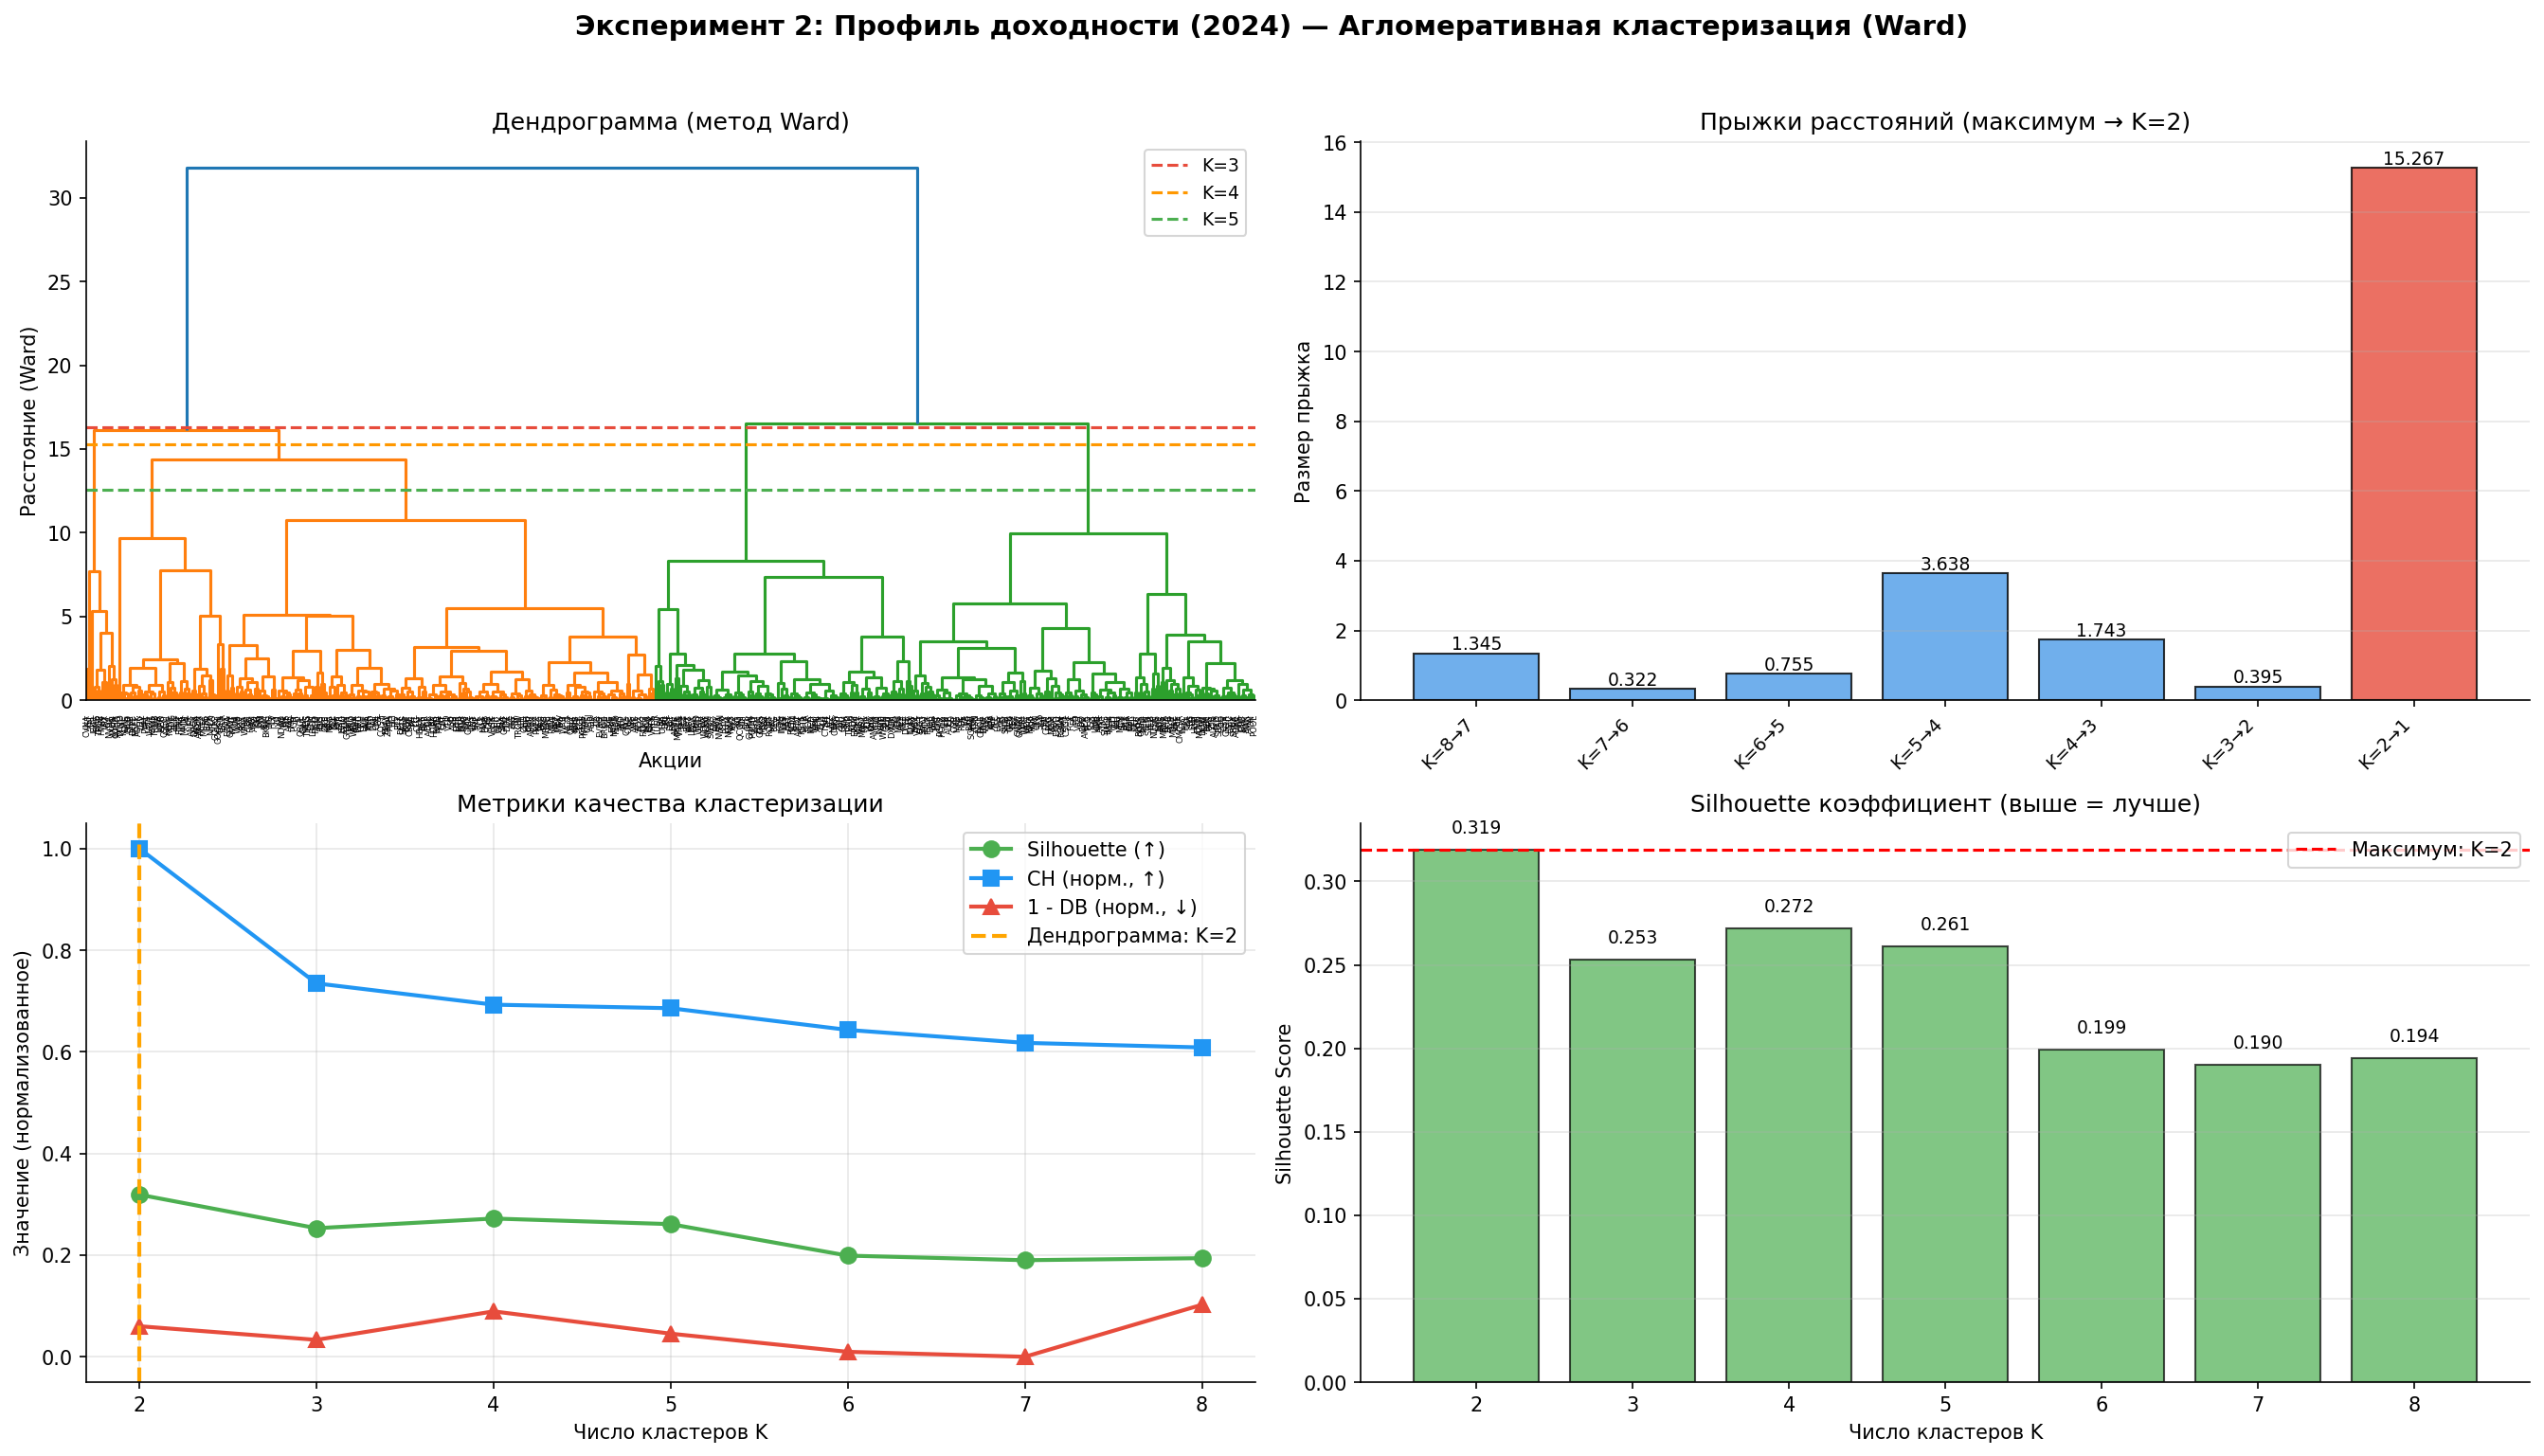


Сводная таблица для диплома

Таблица 1. Метрики качества агломеративной кластеризации
   Silhouette     CH     DB
K                          
2       0.319  243.5  1.157
3       0.253  178.9  1.190
4       0.272  168.7  1.121
5       0.261  167.0  1.175
6       0.199  156.6  1.219
7       0.190  150.4  1.231
8       0.194  148.2  1.105

Таблица 2. Интерпретация оптимальных K

┌────────────────────────────────────────────────────────────────────┐
│  Критерий              │ Оптимальный K │ Значение                 │
├────────────────────────────────────────────────────────────────────┤
│  Дендрограмма (прыжки) │      2       │ max gap = 15.267                  │
│  Silhouette            │      2       │ 0.319                      │
│  Calinski-Harabasz     │      2       │ 243.5                      │
│  Davies-Bouldin        │      8       │ 1.105                      │
└────────────────────────────────────────────────────────────────────┘


ИТОГОВЫЙ ВЕРДИКТ ПО АГЛОМЕРАТИВНОЙ КЛАСТЕРИЗ

In [76]:
# ── АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ: дендрограмма + анализ для K=2..8 ──────────────
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — Агломеративная кластеризация (Ward)")
print("=" * 70)

# Определяем доступные признаки для вывода профилей
available_features = []
feature_names = {}

if 'mom_1m' in X_raw.columns:
    available_features.append('mom_1m')
    feature_names['mom_1m'] = 'mom_1m'
if 'win_rate' in X_raw.columns:
    available_features.append('win_rate')
    feature_names['win_rate'] = 'win_rate'

if 'sharpe' in X_raw.columns:
    available_features.append('sharpe')
    feature_names['sharpe'] = 'Шарп'
if 'mom_12m' in X_raw.columns:
    available_features.append('mom_12m')
    feature_names['mom_12m'] = 'Мом.12М'


print(f"\nДоступные признаки для вывода профилей: {list(feature_names.values())}")

# Строим матрицу связей
Z = linkage(X_scaled, method='ward')

# ── 1. АНАЛИЗ ПРЫЖКОВ (дендрограмма) ─────────────────────────────────────────
N_LAST = 8
last_dists = Z[-N_LAST:, 2]
gaps = np.diff(last_dists)
dendro_k = N_LAST - int(np.argmax(gaps))

print("\nРасстояния последних слияний (дендрограмма):")
for i in range(len(gaps)):
    m = " ← МАКСИМУМ" if gaps[i] == gaps.max() else ""
    print(f"  K={N_LAST-i}→{N_LAST-i-1}: dist={last_dists[i]:.3f}, gap={gaps[i]:.3f}{m}")
print(f"\n→ Дендрограмма предлагает K={dendro_k}")

# ── 2. РАСЧЁТ МЕТРИК ДЛЯ K=2..8 ──────────────────────────────────────────────
print("\n" + "=" * 70)
print("Метрики качества для K=2..8 (агломеративная кластеризация)")
print("=" * 70)

K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': []}
all_labels_agg = {}

print(f"\n{'K':>4} {'Silhouette':>12} {'CH':>12} {'DB':>12}")
print("-" * 45)

for k in K_RANGE:
    # Получаем метки кластеров из дендрограммы
    labels = cut_tree(Z, n_clusters=k).flatten()
    all_labels_agg[k] = labels
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))
    
    print(f"{k:>4} {sil:>12.3f} {ch:>12.1f} {db:>12.3f}")

# Таблица результатов
results_df = pd.DataFrame(results).set_index('K')
print("\n" + results_df.to_string())

# Оптимальные K по разным критериям
best_sil = results_df['Silhouette'].idxmax()
best_ch = results_df['CH'].idxmax()
best_db = results_df['DB'].idxmin()

print(f"\n📈 Оптимальные K по разным критериям:")
print(f"  • Дендрограмма (макс. прыжок):  K = {dendro_k}")
print(f"  • Silhouette (макс):           K = {best_sil}  (значение = {results_df.loc[best_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс):    K = {best_ch}  (значение = {results_df.loc[best_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):        K = {best_db}  (значение = {results_df.loc[best_db, 'DB']:.3f})")

# ── 3. ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (агломеративная кластеризация)")
print("=" * 70)

for k in K_RANGE:
    labels = all_labels_agg[k]
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        row = {'Кластер': cluster_id, 'Акций': n_stocks}
        
        for feat in available_features:
            feat_mean = X_raw.loc[mask, feat].mean()
            row[feature_names[feat]] = round(feat_mean, 3)
        
        profile_data.append(row)
    
    if profile_data:
        profile_df = pd.DataFrame(profile_data)
        print(profile_df.to_string(index=False))
    else:
        print("  Нет данных для вывода профилей")

# ── 4. ВИЗУАЛИЗАЦИЯ: ДЕНДРОГРАММА + СТОЛБЧАТАЯ ДИАГРАММА ─────────────────────
fig = plt.figure(figsize=(18, 10))

# Дендрограмма (левая верхняя)
ax1 = plt.subplot(2, 2, 1)
dendrogram(Z, labels=X_scaled.index.tolist(),
           leaf_rotation=90, leaf_font_size=4,
           color_threshold=0.7 * max(Z[:, 2]), ax=ax1)
ax1.set_xlabel('Акции')
ax1.set_ylabel('Расстояние (Ward)')
ax1.set_title('Дендрограмма (метод Ward)')

# Линии для разных K
for k_cut, color in {3: '#e74c3c', 4: '#FF9800', 5: '#4CAF50'}.items():
    idx = -(k_cut - 1)
    thr = (Z[idx - 1, 2] + Z[idx, 2]) / 2
    ax1.axhline(thr, linestyle='--', linewidth=1.5, color=color, label=f'K={k_cut}')
ax1.legend(fontsize=9)

# Столбчатая диаграмма прыжков (правая верхняя)
ax2 = plt.subplot(2, 2, 2)
k_vals = list(range(N_LAST, N_LAST - len(gaps), -1))
colors = ['#e74c3c' if g == gaps.max() else '#4C9BE8' for g in gaps]
ax2.bar(range(len(gaps)), gaps, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(gaps)))
ax2.set_xticklabels([f'K={k}→{k-1}' for k in k_vals], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Размер прыжка')
ax2.set_title(f'Прыжки расстояний (максимум → K={dendro_k})')
ax2.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, gap in enumerate(gaps):
    ax2.text(i, gap + 0.1, f'{gap:.3f}', ha='center', fontsize=9)

# График метрик качества (нижняя левая)
ax3 = plt.subplot(2, 2, 3)
ax3.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax3.plot(results_df.index, results_df['CH'] / results_df['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм., ↑)')
ax3.plot(results_df.index, 1 - results_df['DB'] / results_df['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм., ↓)')
ax3.axvline(dendro_k, color='orange', linestyle='--', linewidth=2, label=f'Дендрограмма: K={dendro_k}')
ax3.set_xlabel('Число кластеров K')
ax3.set_ylabel('Значение (нормализованное)')
ax3.set_title('Метрики качества кластеризации')
ax3.legend()
ax3.grid(alpha=0.3)

# График Silhouette (нижняя правая)
ax4 = plt.subplot(2, 2, 4)
ax4.bar(results_df.index, results_df['Silhouette'], color='#4CAF50', alpha=0.7, edgecolor='black')
ax4.axhline(results_df.loc[best_sil, 'Silhouette'], color='red', linestyle='--', linewidth=1.5, label=f'Максимум: K={best_sil}')
ax4.set_xlabel('Число кластеров K')
ax4.set_ylabel('Silhouette Score')
ax4.set_title('Silhouette коэффициент (выше = лучше)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for k in results_df.index:
    val = results_df.loc[k, 'Silhouette']
    ax4.text(k, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle(f'{EXP_NAME} — Агломеративная кластеризация (Ward)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_dendrogram_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. ТАБЛИЦА ПО МЕТРИКАМ ДЛЯ ДИПЛОМА ─────────────────────────────────────────
print("\n" + "=" * 70)
print("Сводная таблица для диплома")
print("=" * 70)

print("\nТаблица 1. Метрики качества агломеративной кластеризации")
print(results_df.to_string())

print("\nТаблица 2. Интерпретация оптимальных K")
print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  Критерий              │ Оптимальный K │ Значение                 │
├────────────────────────────────────────────────────────────────────┤
│  Дендрограмма (прыжки) │      {dendro_k}       │ max gap = {max(gaps):.3f}                  │
│  Silhouette            │      {best_sil}       │ {results_df.loc[best_sil, 'Silhouette']:.3f}                      │
│  Calinski-Harabasz     │      {best_ch}       │ {results_df.loc[best_ch, 'CH']:.1f}                      │
│  Davies-Bouldin        │      {best_db}       │ {results_df.loc[best_db, 'DB']:.3f}                      │
└────────────────────────────────────────────────────────────────────┘
""")

# ── 6. ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЕРДИКТ ПО АГЛОМЕРАТИВНОЙ КЛАСТЕРИЗАЦИИ")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  Агломеративная кластеризация (метод Ward)                        │
├────────────────────────────────────────────────────────────────────┤
│  • Дендрограмма предлагает:               K = {dendro_k}                       │
│  • Silhouette:                            K = {best_sil}                       │
│  • Calinski-Harabasz (CH):                K = {best_ch}                       │
│  • Davies-Bouldin (DB):                   K = {best_db}                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = {K_FINAL if 'K_FINAL' in dir() else 4}                    │
│    (на основе интерпретируемости профилей)                         │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_dendrogram_full.png")

## 7. Профили кластеров K=3,4,5


=======================================================  K=2


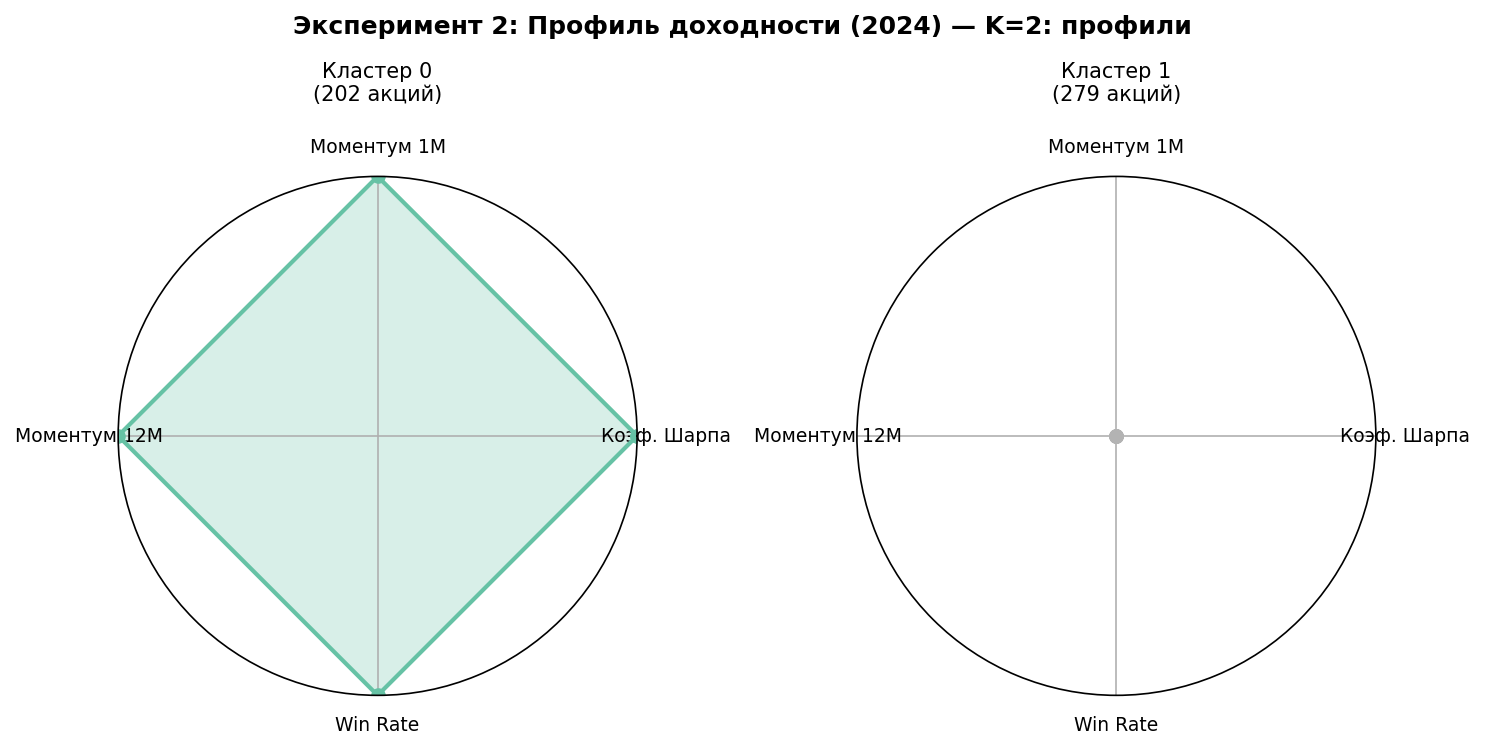


Средние значения (K=2):
           Коэф. Шарпа  Моментум 1М  Моментум 12М  Win Rate  Акций
Кластер 0        1.326       -0.041         0.459     0.553    202
Кластер 1       -0.090       -0.074        -0.025     0.504    279

Интерпретация:
  Кластер 0: Шарп=1.33✓, mom12=0.46↑
  Кластер 1: Шарп=-0.09✗убыток, mom12=-0.02↓

=======================================================  K=3


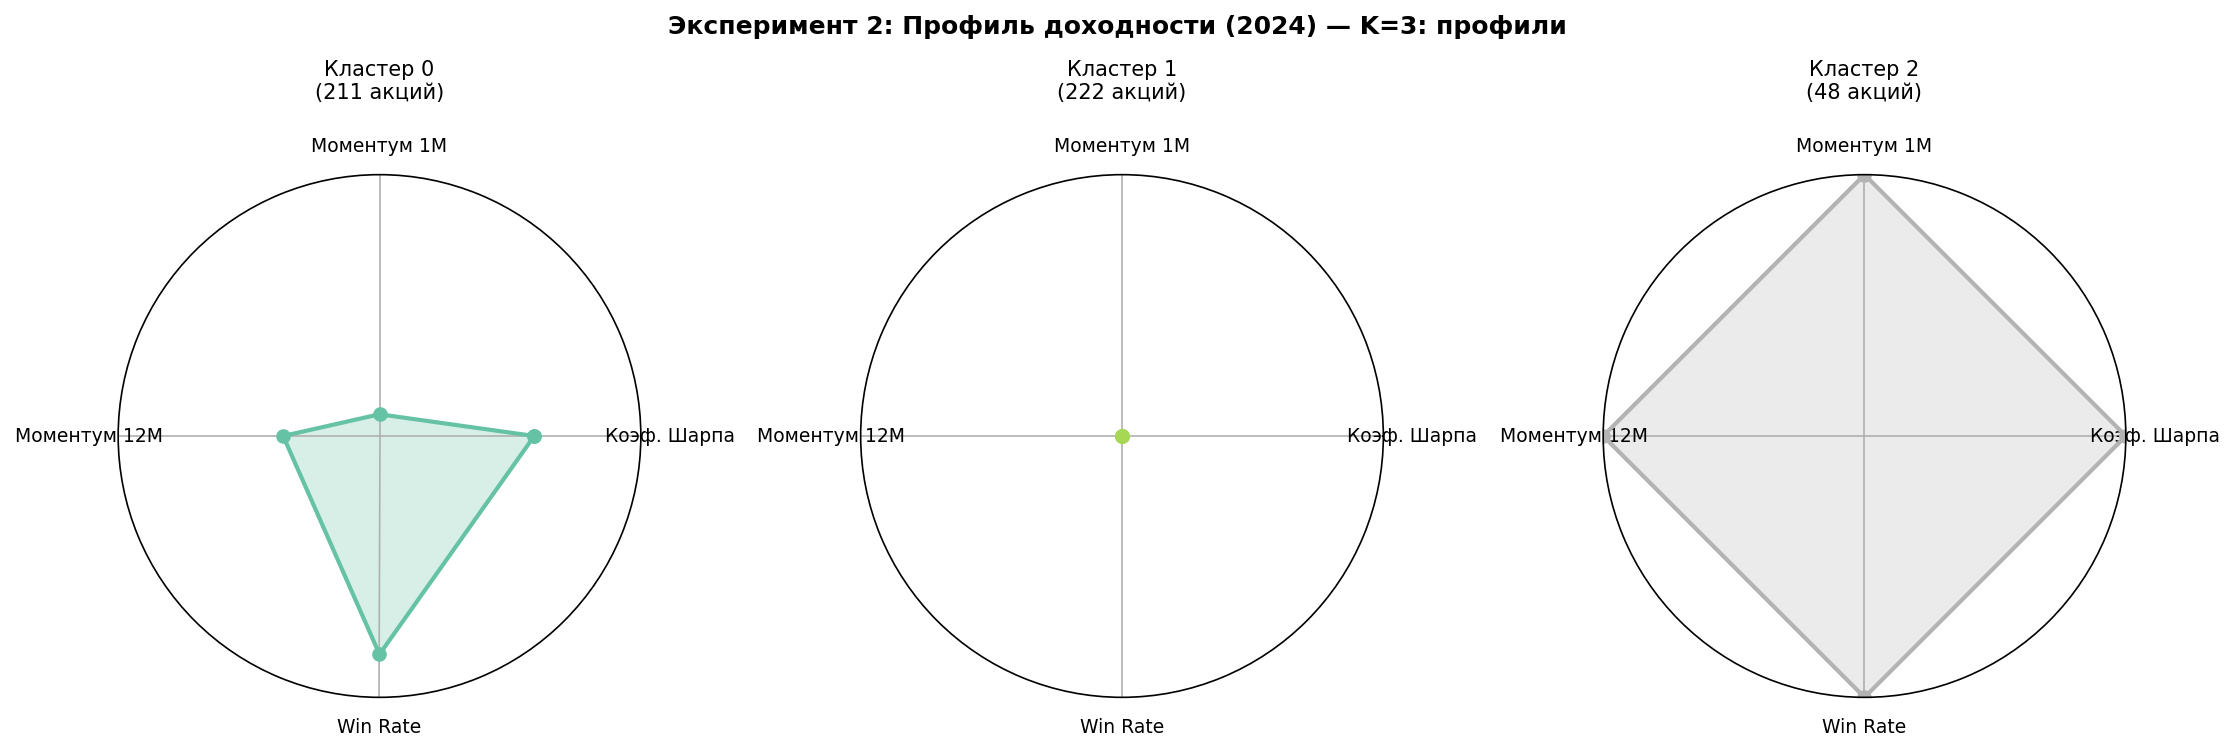


Средние значения (K=3):
           Коэф. Шарпа  Моментум 1М  Моментум 12М  Win Rate  Акций
Кластер 0        0.993       -0.065         0.279     0.546    211
Кластер 1       -0.250       -0.073        -0.067     0.497    222
Кластер 2        1.849        0.019         0.873     0.555     48

Интерпретация:
  Кластер 0: Шарп=0.99✓, mom12=0.28↑
  Кластер 1: Шарп=-0.25✗убыток, mom12=-0.07↓
  Кластер 2: Шарп=1.85✓, mom12=0.87↑

=======================================================  K=4


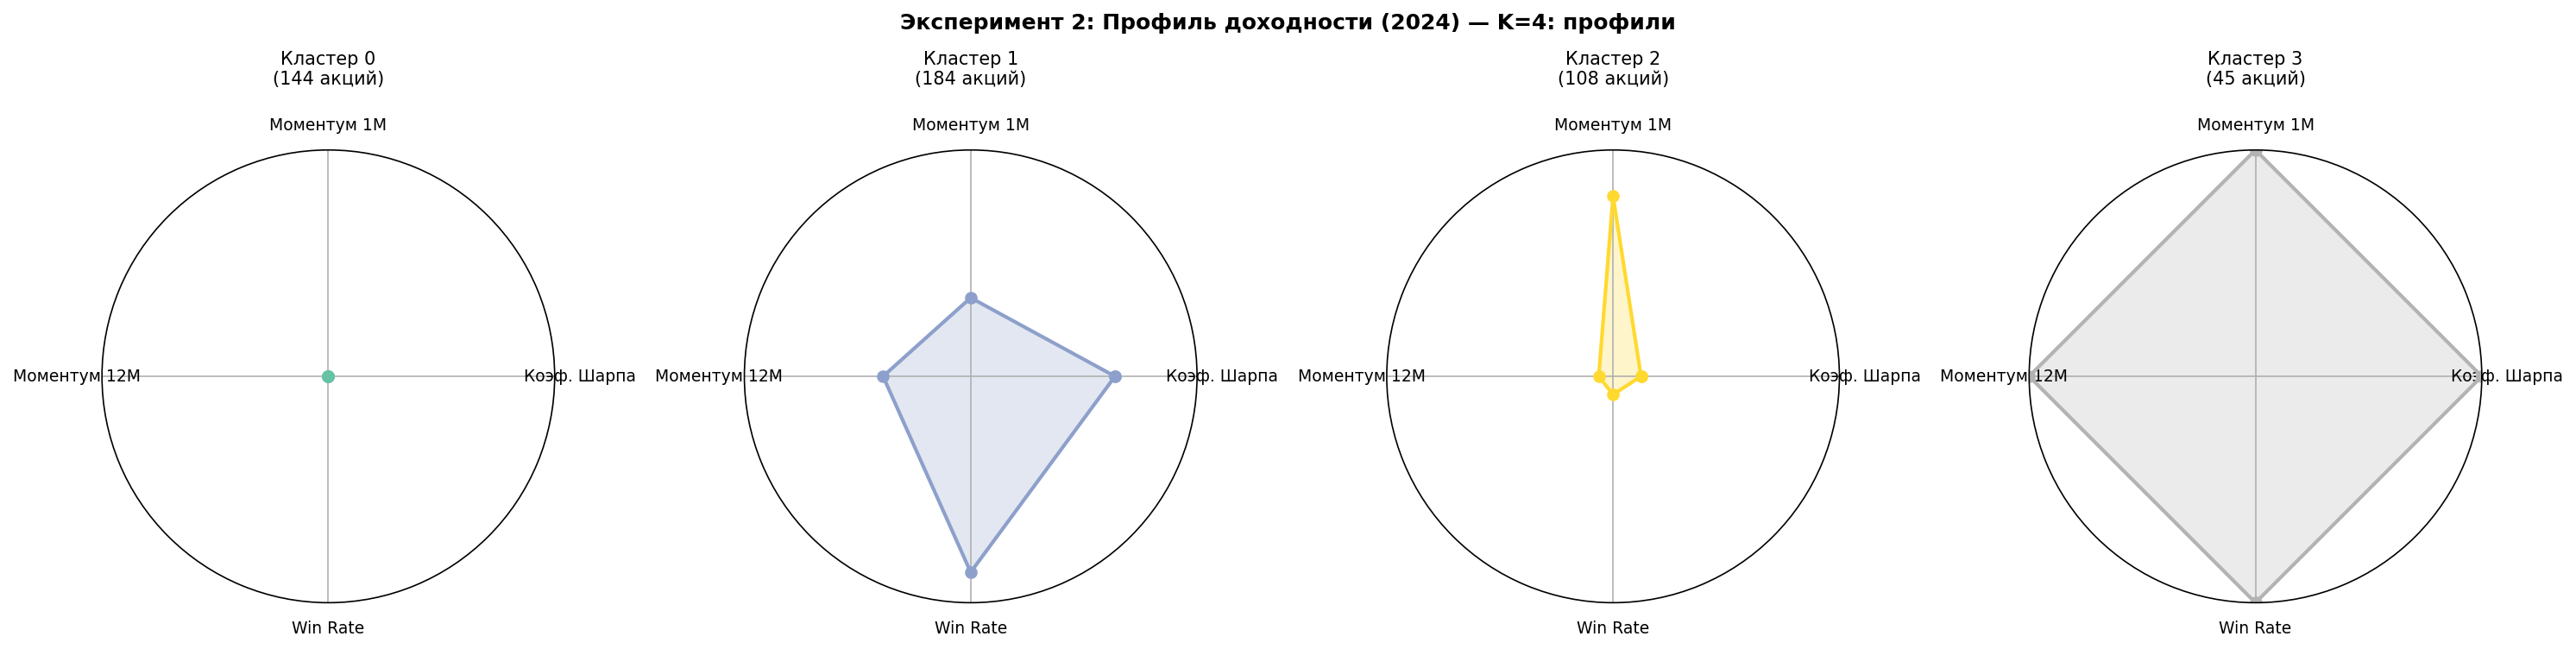


Средние значения (K=4):
           Коэф. Шарпа  Моментум 1М  Моментум 12М  Win Rate  Акций
Кластер 0       -0.282       -0.114        -0.070     0.499    144
Кластер 1        1.091       -0.068         0.306     0.548    184
Кластер 2       -0.016       -0.009        -0.008     0.504    108
Кластер 3        1.872        0.018         0.902     0.556     45

Интерпретация:
  Кластер 0: Шарп=-0.28✗убыток, mom12=-0.07↓
  Кластер 1: Шарп=1.09✓, mom12=0.31↑
  Кластер 2: Шарп=-0.02✗убыток, mom12=-0.01↓
  Кластер 3: Шарп=1.87✓, mom12=0.90↑

=======================================================  K=5


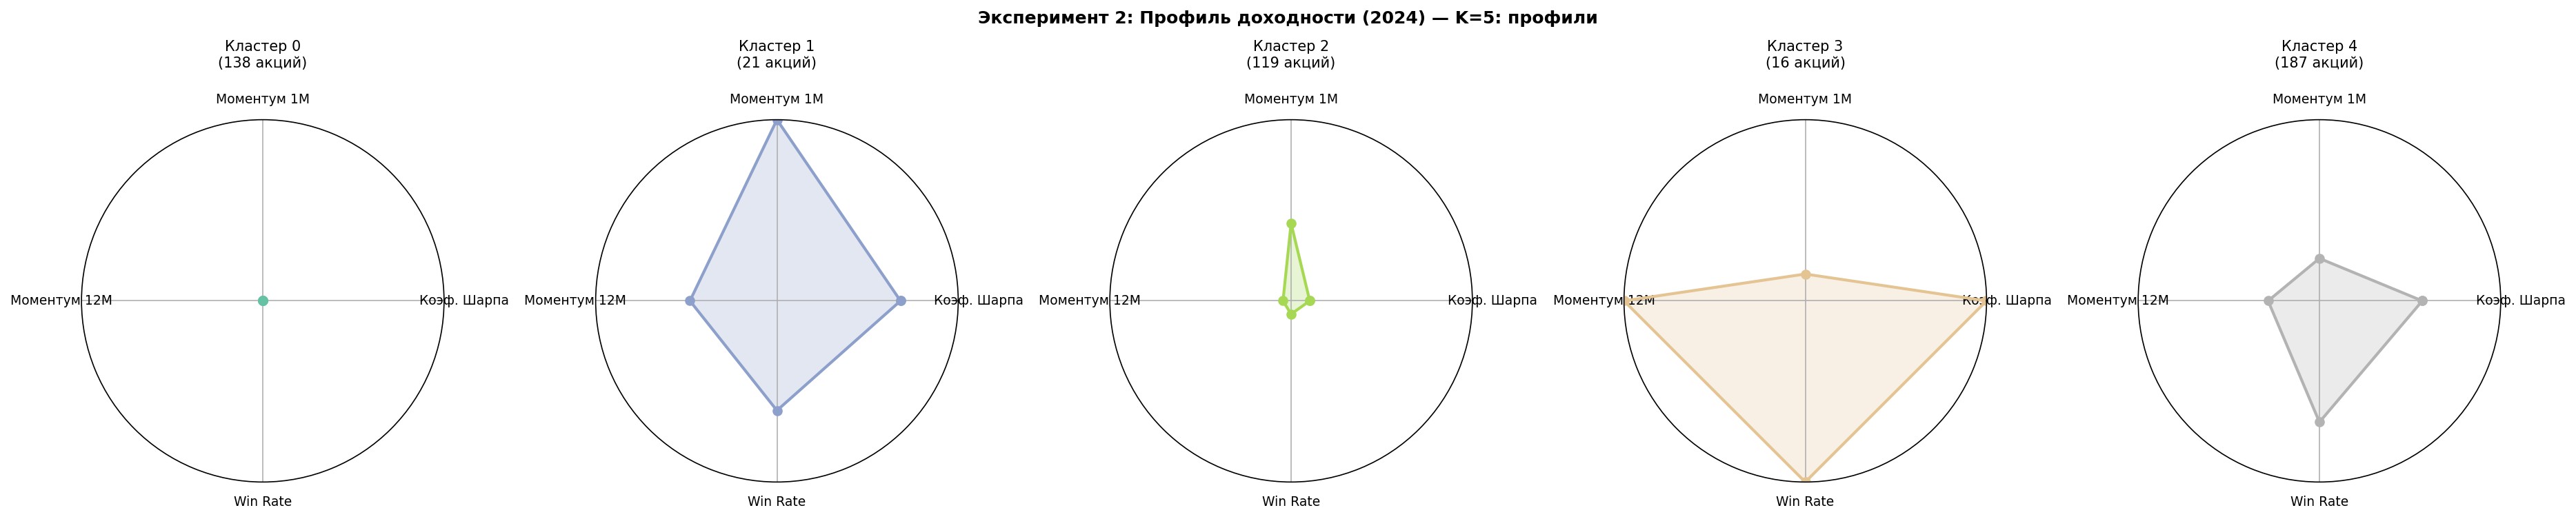


Средние значения (K=5):
           Коэф. Шарпа  Моментум 1М  Моментум 12М  Win Rate  Акций
Кластер 0       -0.272       -0.117        -0.068     0.499    138
Кластер 1        1.440        0.114         0.607     0.544     21
Кластер 2       -0.013       -0.018        -0.005     0.505    119
Кластер 3        2.240       -0.083         1.338     0.573     16
Кластер 4        1.154       -0.063         0.330     0.549    187

Интерпретация:
  Кластер 0: Шарп=-0.27✗убыток, mom12=-0.07↓
  Кластер 1: Шарп=1.44✓, mom12=0.61↑
  Кластер 2: Шарп=-0.01✗убыток, mom12=-0.01↓
  Кластер 3: Шарп=2.24✓, mom12=1.34↑
  Кластер 4: Шарп=1.15✓, mom12=0.33↑


In [77]:
def plot_profiles(X_feat, labels, feature_labels, title, k, save_path=None):
    feats    = list(feature_labels.keys())
    f_lbls   = list(feature_labels.values())
    n_cl     = len(np.unique(labels))
    colors   = plt.cm.Set2(np.linspace(0, 1, n_cl))
    tmp      = X_feat[feats].copy()
    tmp['c'] = labels
    prof_raw = tmp.groupby('c')[feats].mean()
    prof_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(prof_raw),
        columns=feats, index=prof_raw.index
    )
    angles   = np.linspace(0, 2*np.pi, len(feats),
                           endpoint=False).tolist()
    angles  += angles[:1]

    fig = plt.figure(figsize=(5*n_cl, 5))
    fig.suptitle(f'{title} — K={k}: профили',
                 fontsize=12, fontweight='bold')
    for i in range(n_cl):
        ax   = fig.add_subplot(1, n_cl, i+1, polar=True)
        vals = prof_norm.iloc[i].tolist() + [prof_norm.iloc[i].iloc[0]]
        ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i])
        ax.fill(angles, vals, alpha=0.25, color=colors[i])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(f_lbls, size=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_title(f'Кластер {i}\n({(labels==i).sum()} акций)',
                     size=10, pad=18)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    out         = prof_raw.copy()
    out.columns = [feature_labels[c] for c in feats]
    out.index   = [f'Кластер {i}' for i in out.index]
    out['Акций']= [(labels==i).sum() for i in prof_raw.index]
    print(f"\nСредние значения (K={k}):")
    print(out.round(3).to_string())

    print(f"\nИнтерпретация:")
    for i in range(n_cl):
        sh  = prof_raw.iloc[i]['sharpe']
        
        m12 = prof_raw.iloc[i]['mom_12m']
        interp = []
        interp.append(f'Шарп={sh:.2f}' +
                      ('✓' if sh>0.5 else ' слабо' if sh>0 else '✗убыток'))
        
        interp.append(f'mom12={m12:.2f}' + ('↑' if m12>0 else '↓'))
        print(f"  Кластер {i}: {', '.join(interp)}")
    return prof_raw


for k in [2, 3, 4, 5]:
    print(f"\n{'='*55}  K={k}")
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    plot_profiles(X_raw, lbl, LABELS, EXP_NAME, k,
                  f'{SAVE_PREFIX}_profiles_k{k}.png')

## 8. Финальный выбор K и именование

**Обнови K_FINAL и CLUSTER_NAMES после просмотра профилей.**

In [78]:
K_FINAL = 2  # ← обнови

CLUSTER_NAMES = {
    0: ('Опережающие рынок',         '#e74c3c'),  # Шарп < 0
    1: ('Отстающие', '#4CAF50'),  # Шарп > 1
}


km_final   = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
labels_km  = km_final.fit_predict(X_scaled)

agg_final  = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_agg = agg_final.fit_predict(X_scaled)

X_result = X_raw.copy()
X_result['cluster_km']   = labels_km
X_result['cluster_agg']  = labels_agg
X_result['cluster_name'] = [CLUSTER_NAMES[c][0] for c in labels_km]

print(f"K={K_FINAL}, период кластеризации: {MAIN_START} → {MAIN_END}")
for c, (name, _) in CLUSTER_NAMES.items():
    if c < K_FINAL:
        print(f"  {c}: {name} — {(labels_km==c).sum()} акций")

K=2, период кластеризации: 2024-01-01 → 2024-12-31
  0: Опережающие рынок — 202 акций
  1: Отстающие — 279 акций


## 9. GMM

Эксперимент 2: Профиль доходности (2024) — GMM анализ для K=2..8

Доступные признаки для вывода профилей: ['Шарп', 'Мом.12М', 'Мом.1М', 'Win Rate']

   K   Silhouette           CH           DB          BIC          AIC
----------------------------------------------------------------------
   2        0.393         64.6        2.044       3122.0       3000.9
   3        0.130         51.9        5.418       3005.0       2821.3
   4        0.098         86.9        2.436       3018.0       2771.6
   5        0.079         76.5        3.271       3005.0       2696.0
   6        0.067         63.9        2.182       3009.0       2637.4
   7        0.121         90.0        2.196       3004.7       2570.4
   8        0.106         90.0        2.061       3042.5       2545.6

Таблица 1. Метрики качества GMM для K=2..8
   Silhouette    CH     DB     BIC     AIC
K                                         
2       0.393  64.6  2.044  3122.0  3000.9
3       0.130  51.9  5.418  3005.0  2821.3
4   

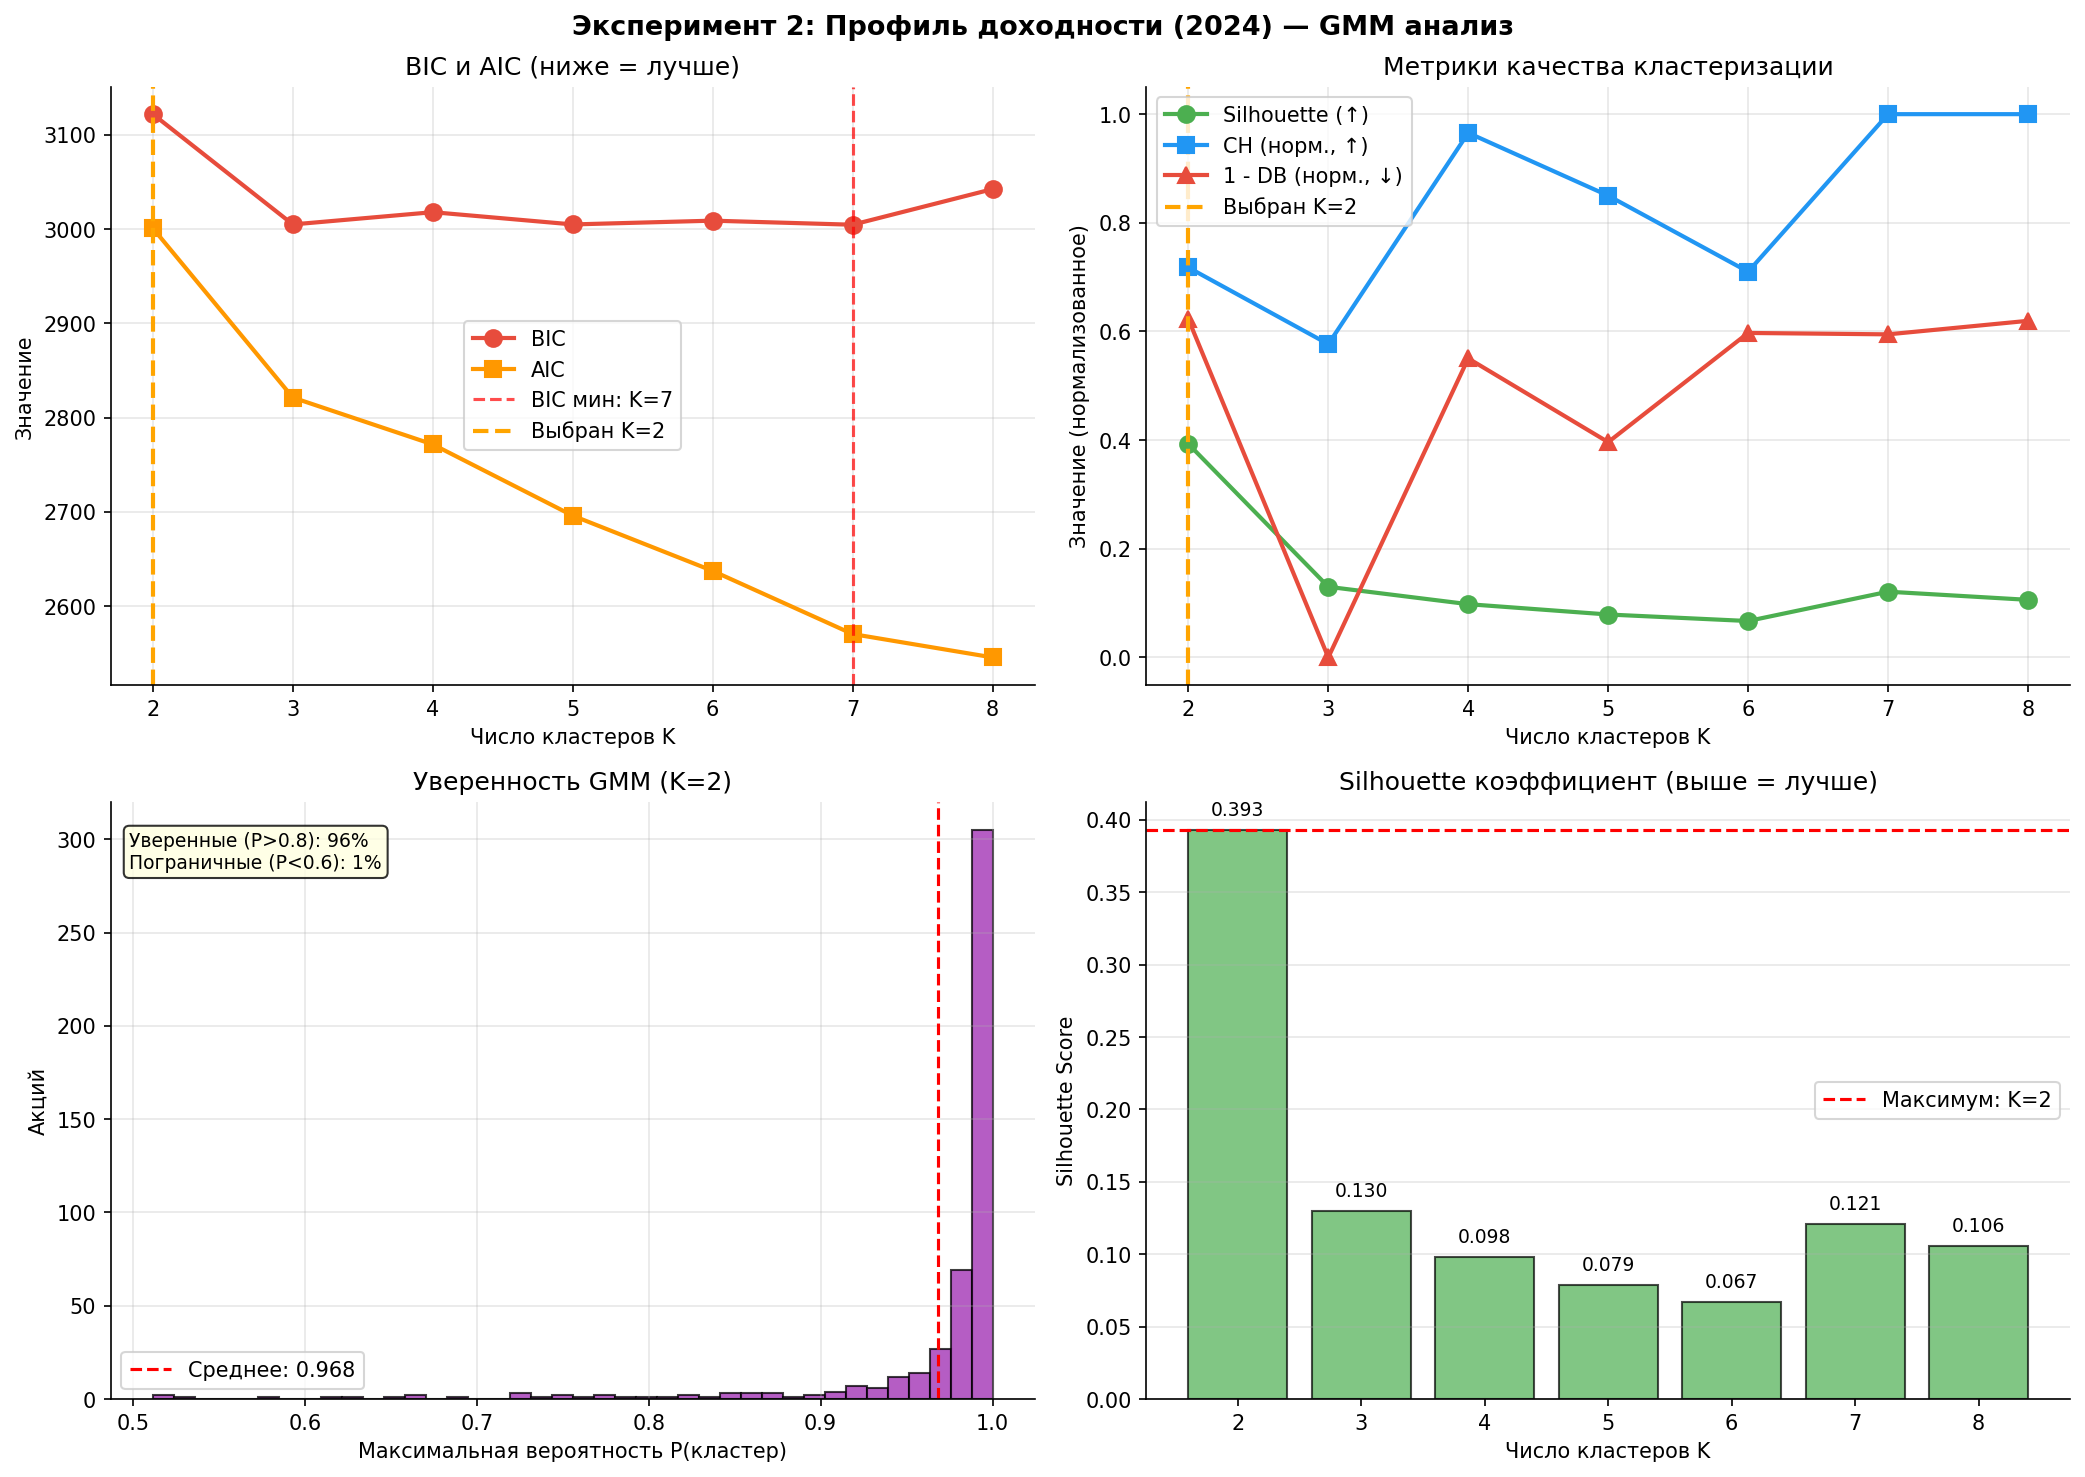


ИТОГОВЫЙ ВЕРДИКТ ПО GMM

┌────────────────────────────────────────────────────────────────────┐
│  GMM (Gaussian Mixture Model) анализ                              │
├────────────────────────────────────────────────────────────────────┤
│  • Silhouette (макс):                    K = 2                       │
│  • Calinski-Harabasz (макс):             K = 7                       │
│  • Davies-Bouldin (мин):                 K = 2                       │
│  • BIC (мин):                            K = 7                       │
│  • AIC (мин):                            K = 8                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = 2                         │
├────────────────────────────────────────────────────────────────────┤
│  Качество классификации:                                          │
│  • BIC = 3122.0                                    │
│  • Средняя уверенность = 0.968                      

In [79]:
# ── GMM АНАЛИЗ ДЛЯ K=2..8 (агломеративная логика) ──────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — GMM анализ для K=2..8")
print("=" * 70)

# Определяем доступные признаки для вывода профилей
available_features = []
feature_names = {}

if 'sigma' in X_raw.columns:
    available_features.append('sigma')
    feature_names['sigma'] = 'σ'
if 'beta' in X_raw.columns:
    available_features.append('beta')
    feature_names['beta'] = 'β'
if 'max_dd' in X_raw.columns:
    available_features.append('max_dd')
    feature_names['max_dd'] = 'Max DD'
if 'sharpe' in X_raw.columns:
    available_features.append('sharpe')
    feature_names['sharpe'] = 'Шарп'
if 'mom_12m' in X_raw.columns:
    available_features.append('mom_12m')
    feature_names['mom_12m'] = 'Мом.12М'
if 'mom_1m' in X_raw.columns:
    available_features.append('mom_1m')
    feature_names['mom_1m'] = 'Мом.1М'
if 'win_rate' in X_raw.columns:
    available_features.append('win_rate')
    feature_names['win_rate'] = 'Win Rate'

print(f"\nДоступные признаки для вывода профилей: {list(feature_names.values())}")

# ── 1. РАСЧЁТ GMM ДЛЯ K=2..8 ─────────────────────────────────────────────────
K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': [], 'BIC': [], 'AIC': []}
all_labels_gmm = {}
all_proba_gmm = {}
all_models_gmm = {}

print(f"\n{'K':>4} {'Silhouette':>12} {'CH':>12} {'DB':>12} {'BIC':>12} {'AIC':>12}")
print("-" * 70)

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    proba = gmm.predict_proba(X_scaled)
    
    all_labels_gmm[k] = labels
    all_proba_gmm[k] = proba
    all_models_gmm[k] = gmm
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))
    results['BIC'].append(round(bic, 1))
    results['AIC'].append(round(aic, 1))
    
    print(f"{k:>4} {sil:>12.3f} {ch:>12.1f} {db:>12.3f} {bic:>12.1f} {aic:>12.1f}")

# Таблица результатов
results_df = pd.DataFrame(results).set_index('K')
print("\n" + "=" * 70)
print("Таблица 1. Метрики качества GMM для K=2..8")
print("=" * 70)
print(results_df.to_string())

# Оптимальные K по разным критериям
best_sil = results_df['Silhouette'].idxmax()
best_ch = results_df['CH'].idxmax()
best_db = results_df['DB'].idxmin()
best_bic = results_df['BIC'].idxmin()
best_aic = results_df['AIC'].idxmin()

print(f"\n📈 Оптимальные K по разным критериям (GMM):")
print(f"  • Silhouette (макс):           K = {best_sil}  (значение = {results_df.loc[best_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс):    K = {best_ch}  (значение = {results_df.loc[best_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):        K = {best_db}  (значение = {results_df.loc[best_db, 'DB']:.3f})")
print(f"  • BIC (мин):                   K = {best_bic}  (значение = {results_df.loc[best_bic, 'BIC']:.0f})")
print(f"  • AIC (мин):                   K = {best_aic}  (значение = {results_df.loc[best_aic, 'AIC']:.0f})")

# ── 2. ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (GMM)")
print("=" * 70)

for k in K_RANGE:
    labels = all_labels_gmm[k]
    proba = all_proba_gmm[k]
    max_proba = proba.max(axis=1)
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        row = {'Кластер': cluster_id, 'Акций': n_stocks, 'Уверенность': round(max_proba[mask].mean(), 3)}
        
        for feat in available_features:
            feat_mean = X_raw.loc[mask, feat].mean()
            row[feature_names[feat]] = round(feat_mean, 3)
        
        profile_data.append(row)
    
    if profile_data:
        profile_df = pd.DataFrame(profile_data)
        print(profile_df.to_string(index=False))
    else:
        print("  Нет данных для вывода профилей")
    
    # Дополнительная статистика по уверенности
    print(f"\n  Уверенность GMM: P>0.9: {(max_proba>0.9).mean()*100:.0f}%, P<0.6: {(max_proba<0.6).mean()*100:.0f}%")

# ── 3. ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ K_FINAL ──────────────────────────────────────────
print("\n" + "=" * 70)
print(f"ДЕТАЛЬНЫЙ АНАЛИЗ GMM ДЛЯ K = {K_FINAL}")
print("=" * 70)

# Берём финальную модель
gmm_final = all_models_gmm[K_FINAL]
labels_gmm = all_labels_gmm[K_FINAL]
proba_gmm = all_proba_gmm[K_FINAL]
max_proba = proba_gmm.max(axis=1)

X_result['cluster_gmm'] = labels_gmm
X_result['gmm_max_prob'] = max_proba

print(f"\nGMM (K={K_FINAL}):")
for c in range(K_FINAL):
    mask = labels_gmm == c
    if mask.sum() > 0:
        print(f"  Кластер {c}: {mask.sum()} акций, средняя уверенность {max_proba[mask].mean():.3f}")

print(f"\n  P > 0.9 (уверенные):     {(max_proba>0.9).sum()} акций ({(max_proba>0.9).mean()*100:.0f}%)")
print(f"  P > 0.8:                 {(max_proba>0.8).sum()} акций ({(max_proba>0.8).mean()*100:.0f}%)")
print(f"  P < 0.6 (пограничные):   {(max_proba<0.6).sum()} акций ({(max_proba<0.6).mean()*100:.0f}%)")
print(f"  Средняя уверенность:     {max_proba.mean():.3f}")
print(f"  BIC = {gmm_final.bic(X_scaled):.1f}")
print(f"  AIC = {gmm_final.aic(X_scaled):.1f}")

# ── 4. ТОП-15 ПОГРАНИЧНЫХ АКЦИЙ ──────────────────────────────────────────────
print(f"\n📌 Топ-15 акций с наибольшей неопределённостью (пограничные):")
uncertainty = 1 - max_proba
uncertain_df = pd.DataFrame({
    'Акция': X_raw.index,
    'Кластер GMM': labels_gmm,
    'Max P(GMM)': max_proba.round(3),
    'Неопределённость': uncertainty.round(3)
}).sort_values('Неопределённость', ascending=False).head(15)
print(uncertain_df.to_string(index=False))

# ── 5. ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{EXP_NAME} — GMM анализ', fontsize=13, fontweight='bold')

# График 1: BIC и AIC
ax = axes[0, 0]
ax.plot(results_df.index, results_df['BIC'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='BIC')
ax.plot(results_df.index, results_df['AIC'], 's-', color='#FF9800', linewidth=2, markersize=8, label='AIC')
ax.axvline(best_bic, color='red', linestyle='--', alpha=0.7, label=f'BIC мин: K={best_bic}')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение')
ax.set_title('BIC и AIC (ниже = лучше)')
ax.legend()
ax.grid(alpha=0.3)

# График 2: Метрики качества
ax = axes[0, 1]
ax.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax.plot(results_df.index, results_df['CH'] / results_df['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм., ↑)')
ax.plot(results_df.index, 1 - results_df['DB'] / results_df['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм., ↓)')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение (нормализованное)')
ax.set_title('Метрики качества кластеризации')
ax.legend()
ax.grid(alpha=0.3)

# График 3: Распределение уверенности GMM
ax = axes[1, 0]
ax.hist(max_proba, bins=40, color='#9C27B0', alpha=0.75, edgecolor='black')
ax.axvline(max_proba.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {max_proba.mean():.3f}')
ax.set_xlabel('Максимальная вероятность P(кластер)')
ax.set_ylabel('Акций')
ax.set_title(f'Уверенность GMM (K={K_FINAL})')
ax.legend()
ax.grid(alpha=0.3)

pct_confident = (max_proba > 0.8).mean() * 100
pct_uncertain = (max_proba < 0.6).mean() * 100
ax.text(0.02, 0.95, f'Уверенные (P>0.8): {pct_confident:.0f}%\nПограничные (P<0.6): {pct_uncertain:.0f}%',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 4: Сравнение Silhouette по K
ax = axes[1, 1]
ax.bar(results_df.index, results_df['Silhouette'], color='#4CAF50', alpha=0.7, edgecolor='black')
ax.axhline(results_df.loc[best_sil, 'Silhouette'], color='red', linestyle='--', linewidth=1.5, label=f'Максимум: K={best_sil}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette коэффициент (выше = лучше)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for k in results_df.index:
    val = results_df.loc[k, 'Silhouette']
    ax.text(k, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_gmm_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЕРДИКТ ПО GMM")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  GMM (Gaussian Mixture Model) анализ                              │
├────────────────────────────────────────────────────────────────────┤
│  • Silhouette (макс):                    K = {best_sil}                       │
│  • Calinski-Harabasz (макс):             K = {best_ch}                       │
│  • Davies-Bouldin (мин):                 K = {best_db}                       │
│  • BIC (мин):                            K = {best_bic}                       │
│  • AIC (мин):                            K = {best_aic}                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = {K_FINAL}                         │
├────────────────────────────────────────────────────────────────────┤
│  Качество классификации:                                          │
│  • BIC = {gmm_final.bic(X_scaled):.1f}                                    │
│  • Средняя уверенность = {max_proba.mean():.3f}                            │
│  • Уверенных (P>0.8): {pct_confident:.0f}% акций                           │
│  • Пограничных (P<0.6): {pct_uncertain:.0f}% акций                         │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_gmm_full_analysis.png")

## 10. DBSCAN

In [80]:
k_nbrs       = 2 * len(FEATURES)
nbrs         = NearestNeighbors(n_neighbors=k_nbrs).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dists      = np.sort(distances[:, -1])[::-1]
x_v          = np.arange(len(k_dists))
p1, p2       = np.array([x_v[0], k_dists[0]]), \
               np.array([x_v[-1], k_dists[-1]])
dlp          = np.abs(np.cross(
    p2-p1, p1-np.column_stack([x_v, k_dists])
))
dlp         /= np.linalg.norm(p2-p1)
elbow_eps    = float(k_dists[np.argmax(dlp)])

EPS, MIN_SAMP = round(elbow_eps, 2), 5
labels_db     = DBSCAN(eps=EPS,
                       min_samples=MIN_SAMP).fit_predict(X_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = int((labels_db == -1).sum())
noise_tickers = X_raw.index[labels_db == -1].tolist()

print(f"DBSCAN (eps={EPS}): {n_clusters_db} кластеров, {n_noise} выбросов")
if noise_tickers:
    print("\nВыбросы (экстремальный профиль доходности в 2024):")
    nd = X_raw.loc[noise_tickers, FEATURES].copy()
    nd['sector'] = meta.loc[
        nd.index.intersection(meta.index), 'sector'
    ]
    print(nd.round(3).to_string())

X_result['cluster_db'] = labels_db
valid_mask = labels_db != -1
sil_db = silhouette_score(
    X_scaled[valid_mask], labels_db[valid_mask]
) if n_clusters_db > 1 and valid_mask.sum() > n_clusters_db \
  else np.nan

DBSCAN (eps=1.03): 1 кластеров, 19 выбросов

Выбросы (экстремальный профиль доходности в 2024):
        sharpe  mom_1m  mom_12m  win_rate                  sector
ticker                                                           
APTV    -0.951   0.083   -0.336     0.506  Consumer Discretionary
GOOG     1.139   0.129    0.369     0.606  Communication Services
GOOGL    1.134   0.131    0.369     0.594  Communication Services
AVGO     1.602   0.479    1.127     0.522  Information Technology
BA      -1.083   0.158   -0.322     0.474             Industrials
CVNA     2.090  -0.174    2.834     0.538  Consumer Discretionary
CIEN     1.675   0.229    0.885     0.578  Information Technology
CVS     -1.433  -0.267   -0.420     0.510             Health Care
FIX      1.794  -0.118    1.086     0.562             Industrials
LULU    -0.642   0.202   -0.246     0.502  Consumer Discretionary
NVDA     2.139   0.016    1.777     0.558  Information Technology
TER      0.494   0.172    0.152     0.522  Inf

## 11. Индекс неопределённости

Эксперимент 2: Профиль доходности (2024) — Индекс неопределённости кластера (CUI)

Индекс неопределённости (K-Means vs Agglomerative vs GMM):
  • Ядро (все согласны):         277 акций (58%)
  • Пограничные (2/3 согласны):  204 акций (42%)
  • Конфликт (все разные):       0 акций (0%)


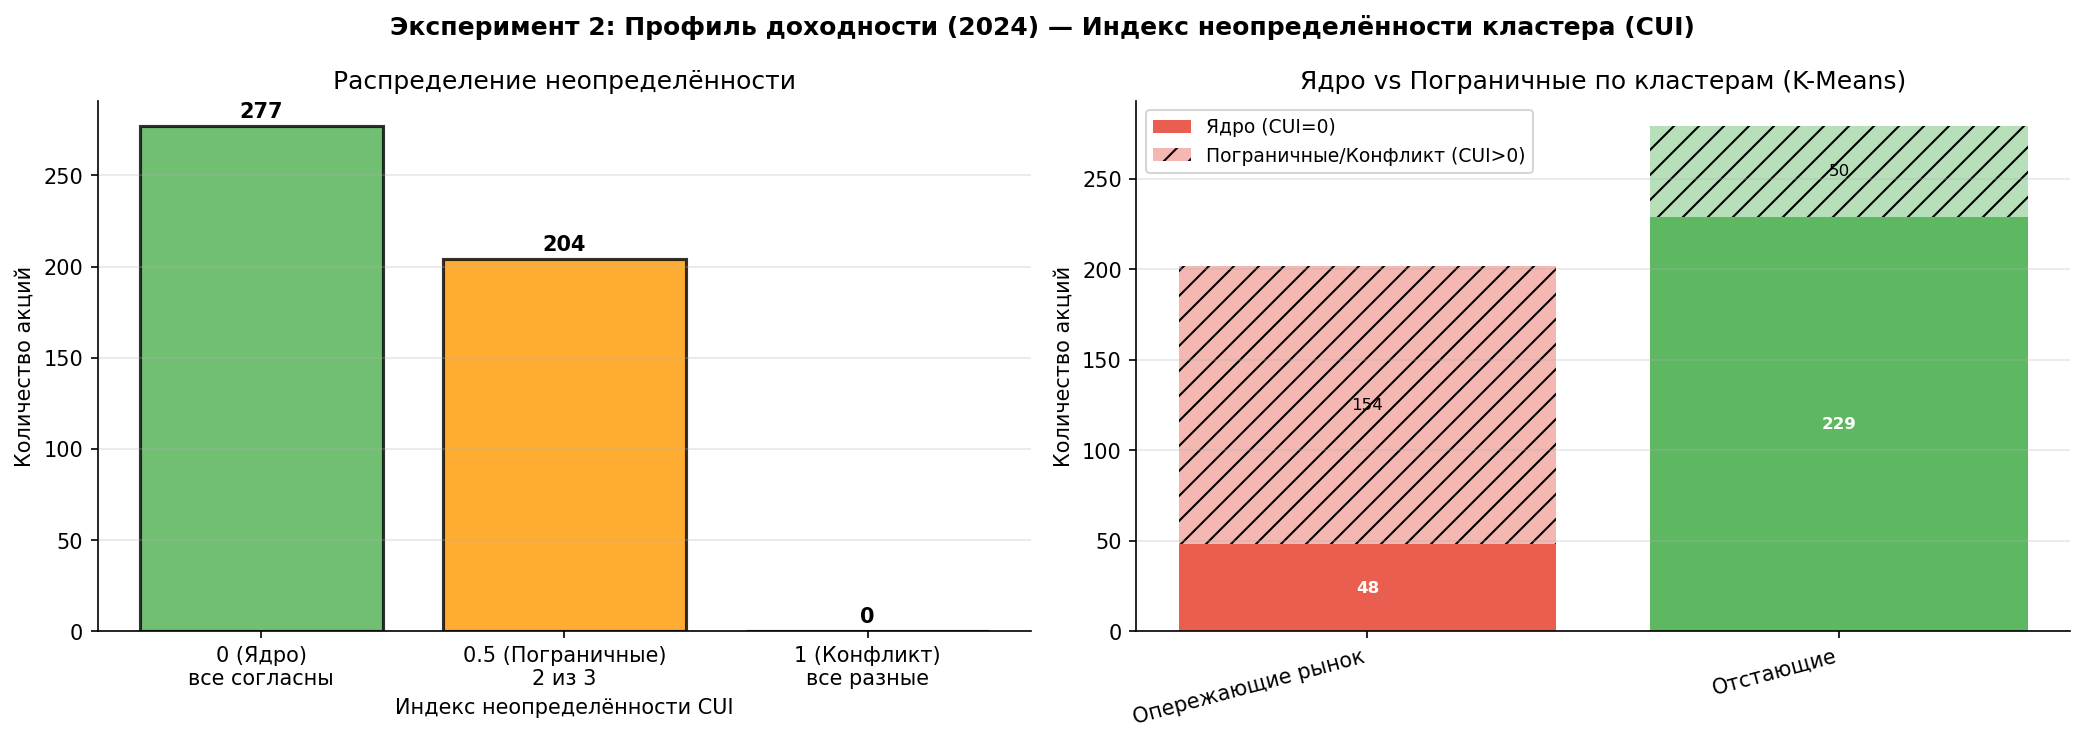


Акции с наибольшей неопределённостью (алгоритмы расходятся)
    Акция         KM кластер      Agglomerative                GMM  CUI   Шарп  Мом.12М  Мом.1М  Win Rate
0    AAPL  Опережающие рынок  Опережающие рынок          Отстающие  0.5  1.152    0.309   0.074     0.566
140  ORLY  Опережающие рынок  Опережающие рынок          Отстающие  0.5  1.016    0.254  -0.052     0.582
130  MRNA          Отстающие          Отстающие  Опережающие рынок  0.5 -1.301   -0.601  -0.092     0.430
131  MRSH  Опережающие рынок  Опережающие рынок          Отстающие  0.5  0.698    0.139  -0.091     0.562
132    MS  Опережающие рынок  Опережающие рынок          Отстающие  0.5  1.261    0.392  -0.042     0.566
133  MSFT  Опережающие рынок  Опережающие рынок          Отстающие  0.5  0.551    0.140   0.004     0.538
134   MSI  Опережающие рынок  Опережающие рынок          Отстающие  0.5  2.187    0.505  -0.072     0.590
135  NDAQ  Опережающие рынок  Опережающие рынок          Отстающие  0.5  1.500    0.348  -0

In [81]:
# ── ИНДЕКС НЕОПРЕДЕЛЁННОСТИ (CUI) С ВИЗУАЛИЗАЦИЕЙ ДЛЯ СРАВНЕНИЯ ──────────────────
from scipy.optimize import linear_sum_assignment

print("=" * 70)
print(f"{EXP_NAME} — Индекс неопределённости кластера (CUI)")
print("=" * 70)

# Функция выравнивания меток
def align_labels(ref, to_align, k):
    """Переназначает метки чтобы максимизировать совпадение с ref."""
    cost = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            cost[i, j] = -np.sum((ref == i) & (to_align == j))
    ri, ci = linear_sum_assignment(cost)
    m = dict(zip(ci, ri))
    return np.array([m.get(l, l) for l in to_align])

# Выравниваем метки агломеративной и GMM относительно K-Means
labels_agg_aligned = align_labels(labels_km, labels_agg, K_FINAL)
labels_gmm_aligned = align_labels(labels_km, labels_gmm, K_FINAL)

# Индекс неопределённости
stacked = np.column_stack([labels_km, labels_agg_aligned, labels_gmm_aligned])
n_unique_labels = np.array([len(np.unique(row)) for row in stacked])
uncertainty_idx = (n_unique_labels - 1) / (3 - 1)  # [0, 0.5, 1]

# Сохраняем в результат
X_result['uncertainty_idx'] = uncertainty_idx

# Статистика
n_core = (uncertainty_idx == 0.0).sum()
n_border = (uncertainty_idx == 0.5).sum()
n_conflict = (uncertainty_idx == 1.0).sum()

print(f"\nИндекс неопределённости (K-Means vs Agglomerative vs GMM):")
print(f"  • Ядро (все согласны):         {n_core} акций ({n_core/len(X_result)*100:.0f}%)")
print(f"  • Пограничные (2/3 согласны):  {n_border} акций ({n_border/len(X_result)*100:.0f}%)")
print(f"  • Конфликт (все разные):       {n_conflict} акций ({n_conflict/len(X_result)*100:.0f}%)")

# ── ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{EXP_NAME} — Индекс неопределённости кластера (CUI)',
             fontsize=12, fontweight='bold')

# График 1: Распределение неопределённости (ОТДЕЛЬНЫЕ СТОЛБЦЫ)
ax = axes[0]
# Считаем количество для каждого значения
core_count = (uncertainty_idx == 0.0).sum()
border_count = (uncertainty_idx == 0.5).sum()
conflict_count = (uncertainty_idx == 1.0).sum()

# Рисуем три отдельных столбца
bars = ax.bar([0, 1, 2], [core_count, border_count, conflict_count],
              color=['#4CAF50', '#FF9800', '#e74c3c'],
              alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['0 (Ядро)\nвсе согласны', '0.5 (Пограничные)\n2 из 3', '1 (Конфликт)\nвсе разные'])
ax.set_xlabel('Индекс неопределённости CUI')
ax.set_ylabel('Количество акций')
ax.set_title('Распределение неопределённости')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, count in zip(bars, [core_count, border_count, conflict_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontsize=10, fontweight='bold')

# График 2: Ядро vs Пограничные по кластерам K-Means
ax = axes[1]

# Определяем цвета для кластеров
try:
    cluster_colors = {c: CLUSTER_NAMES[c][1] for c in range(K_FINAL)}
    cluster_names_dict = {c: CLUSTER_NAMES[c][0] for c in range(K_FINAL)}
except:
    cluster_colors = {0: '#4CAF50', 1: '#FF9800', 2: '#e74c3c', 3: '#2196F3'}
    cluster_names_dict = {0: 'Защитные', 1: 'Умеренно-агрессивные', 2: 'Агрессивные', 3: 'Рыночные'}

# Считаем ядро и границу по каждому кластеру
core_counts = []
border_counts = []
cluster_labels = []

for c_id in range(K_FINAL):
    mask = labels_km == c_id
    core_cnt = ((uncertainty_idx == 0) & mask).sum()
    border_cnt = ((uncertainty_idx > 0) & mask).sum()
    
    core_counts.append(core_cnt)
    border_counts.append(border_cnt)
    cluster_labels.append(cluster_names_dict.get(c_id, f'Кластер {c_id}'))

# Строим стековую столбчатую диаграмму
x_positions = np.arange(K_FINAL)
colors = [cluster_colors.get(i, '#999') for i in range(K_FINAL)]

bars_core = ax.bar(x_positions, core_counts, color=colors, 
                   alpha=0.9, label='Ядро (CUI=0)')
bars_border = ax.bar(x_positions, border_counts, bottom=core_counts,
                     color=colors, alpha=0.4, label='Пограничные/Конфликт (CUI>0)', hatch='//')

ax.set_xticks(x_positions)
ax.set_xticklabels(cluster_labels, rotation=15, ha='right')
ax.set_ylabel('Количество акций')
ax.set_title('Ядро vs Пограничные по кластерам (K-Means)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (core, border) in enumerate(zip(core_counts, border_counts)):
    if core > 0:
        ax.text(i, core/2, str(core), ha='center', va='center', fontsize=8, color='white', fontweight='bold')
    if border > 0:
        ax.text(i, core + border/2, str(border), ha='center', va='center', fontsize=8, color='black')

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ТОП-15 АКЦИЙ С НАИБОЛЬШЕЙ НЕОПРЕДЕЛЁННОСТЬЮ ─────────────────────────────
print("\n" + "=" * 70)
print("Акции с наибольшей неопределённостью (алгоритмы расходятся)")
print("=" * 70)

# Получаем названия кластеров для каждого алгоритма
km_names = [cluster_names_dict.get(l, str(l)) for l in labels_km]
agg_names = [cluster_names_dict.get(l, str(l)) for l in labels_agg_aligned]
gmm_names = [cluster_names_dict.get(l, str(l)) for l in labels_gmm_aligned]

# Собираем данные для конфликтных акций
conflict_data = []
for i, (ticker, u_idx) in enumerate(zip(X_raw.index, uncertainty_idx)):
    if u_idx > 0:
        row = {
            'Акция': ticker,
            'KM кластер': km_names[i],
            'Agglomerative': agg_names[i],
            'GMM': gmm_names[i],
            'CUI': round(u_idx, 3)
        }
        # Добавляем доступные метрики
        for feat in available_features:
            if feat in X_raw.columns:
                row[feature_names.get(feat, feat)] = round(X_raw.loc[ticker, feat], 3)
        conflict_data.append(row)

conflict_df = pd.DataFrame(conflict_data)
if len(conflict_df) > 0:
    display_cols = ['Акция', 'KM кластер', 'Agglomerative', 'GMM', 'CUI'] + \
                   [feature_names.get(f, f) for f in available_features if f in X_raw.columns]
    display_cols = [c for c in display_cols if c in conflict_df.columns]
    print(conflict_df[display_cols].sort_values('CUI', ascending=False).head(15).to_string())
else:
    print("  Нет акций с неопределённостью > 0")

# ── ДОПОЛНИТЕЛЬНО: АКЦИИ С ПОЛНЫМ КОНСЕНСУСОМ (CUI=0) ─────────────────────────
print("\n" + "=" * 70)
print("Акции с полным консенсусом (CUI=0) — ядро кластеров")
print("=" * 70)

core_data = []
for i, (ticker, u_idx) in enumerate(zip(X_raw.index, uncertainty_idx)):
    if u_idx == 0:
        core_data.append({
            'Акция': ticker,
            'KM кластер': km_names[i],
        })

core_df = pd.DataFrame(core_data)

for c_id in range(K_FINAL):
    cluster_name = cluster_names_dict.get(c_id, f'Кластер {c_id}')
    cluster_core = core_df[core_df['KM кластер'] == cluster_name]
    if len(cluster_core) > 0:
        print(f"\n{cluster_name} ({len(cluster_core)} акций):")
        tickers = cluster_core['Акция'].tolist()[:5]
        print(f"  {', '.join(tickers)}")
        if len(cluster_core) > 5:
            print(f"  ... и ещё {len(cluster_core) - 5} акций")

# ── ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫВОД ПО ИНДЕКСУ НЕОПРЕДЕЛЁННОСТИ")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  CUI (Cluster Uncertainty Index)                                   │
├────────────────────────────────────────────────────────────────────┤
│  • Ядро (CUI=0):     {n_core:4d} акций ({n_core/len(X_result)*100:.0f}%) — все три алгоритма согласны          │
│  • Пограничные:      {n_border:4d} акций ({n_border/len(X_result)*100:.0f}%) — два из трёх согласны             │
│  • Конфликт:         {n_conflict:4d} акций ({n_conflict/len(X_result)*100:.0f}%) — все три разошлись            │
├────────────────────────────────────────────────────────────────────┤
│  Практический вывод:                                               │
│    • CUI=0 → высокая уверенность в классификации                  │
│    • CUI>0 → требуется дополнительный анализ                      │
│    • CUI=1 → полное расхождение алгоритмов                        │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_uncertainty.png")

## 12. Анализ стабильности — три независимых года

Проверяем: совпадают ли кластеры 2024 года с кластерами
2022 и 2023 годов?

Каждый год — независимая кластеризация на данных этого года.
Это соответствует годовому горизонту моментума
(Jegadeesh & Titman, 1993).

In [82]:
SUBPERIODS = {
    '2022': ('2022-01-01', '2022-12-31'),
    '2023': ('2023-01-01', '2023-12-31'),
    '2024': ('2024-01-01', '2024-12-31'),
}

subperiod_labels = {}
tickers_main     = X_raw.index.tolist()

for period_name, (start, end) in SUBPERIODS.items():
    print(f"Подпериод {period_name}...", end=' ')

    sub_df = build_features_for_period(start, end, min_days=100)

    if len(sub_df) == 0:
        print("ОШИБКА: нет данных")
        continue

    sub_X = pd.DataFrame(
        RobustScaler().fit_transform(sub_df[FEATURES]),
        index=sub_df.index, columns=FEATURES
    )
    sub_km  = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
    sub_lbl = sub_km.fit_predict(sub_X)
    subperiod_labels[period_name] = pd.Series(
        sub_lbl, index=sub_df.index
    )
    print(f"{len(sub_df)} акций")

# Стабильность
common = sorted(
    set.intersection(*[
        set(v.index) for v in subperiod_labels.values()
    ]).intersection(set(tickers_main))
)

stability_df = pd.DataFrame(
    {p: subperiod_labels[p].loc[common] for p in SUBPERIODS}
)
full_labels_c = pd.Series(labels_km, index=X_raw.index).loc[common]

for col in stability_df.columns:
    stability_df[col] = align_labels(
        full_labels_c.values,
        stability_df[col].values,
        K_FINAL
    )

stability_df['n_unique'] = \
    stability_df[list(SUBPERIODS.keys())].nunique(axis=1)
stability_df['stable']   = stability_df['n_unique'] == 1
stability_df['full_km']  = full_labels_c.values

n_stable   = stability_df['stable'].sum()
pct_stable = n_stable / len(stability_df) * 100

print(f"\nСтабильность (2022 / 2023 / 2024 — три отдельных года):")
print(f"  Стабильных: {n_stable} ({pct_stable:.0f}%)")
print(f"  Меняли кластер: {len(stability_df)-n_stable}")
print("\nСтабильность по кластерам:")
for c in range(K_FINAL):
    mask = stability_df['full_km'] == c
    if mask.sum() > 0:
        stab = stability_df.loc[mask,'stable'].mean()*100
        print(f"  {CLUSTER_NAMES[c][0]}: {stab:.0f}%")

print("\nВажное замечание:")
print("  Низкая стабильность — ожидаемый результат.")
print("  Доходностные кластеры отражают текущий режим рынка,")
print("  а не долгосрочные структурные свойства акции.")
print("  (Jegadeesh & Titman, 1993; Moskowitz et al., 2012)")

Подпериод 2022... 481 акций
Подпериод 2023... 481 акций
Подпериод 2024... 481 акций

Стабильность (2022 / 2023 / 2024 — три отдельных года):
  Стабильных: 211 (44%)
  Меняли кластер: 270

Стабильность по кластерам:
  Опережающие рынок: 41%
  Отстающие: 46%

Важное замечание:
  Низкая стабильность — ожидаемый результат.
  Доходностные кластеры отражают текущий режим рынка,
  а не долгосрочные структурные свойства акции.
  (Jegadeesh & Titman, 1993; Moskowitz et al., 2012)


## 13. Силуэтный анализ и t-SNE

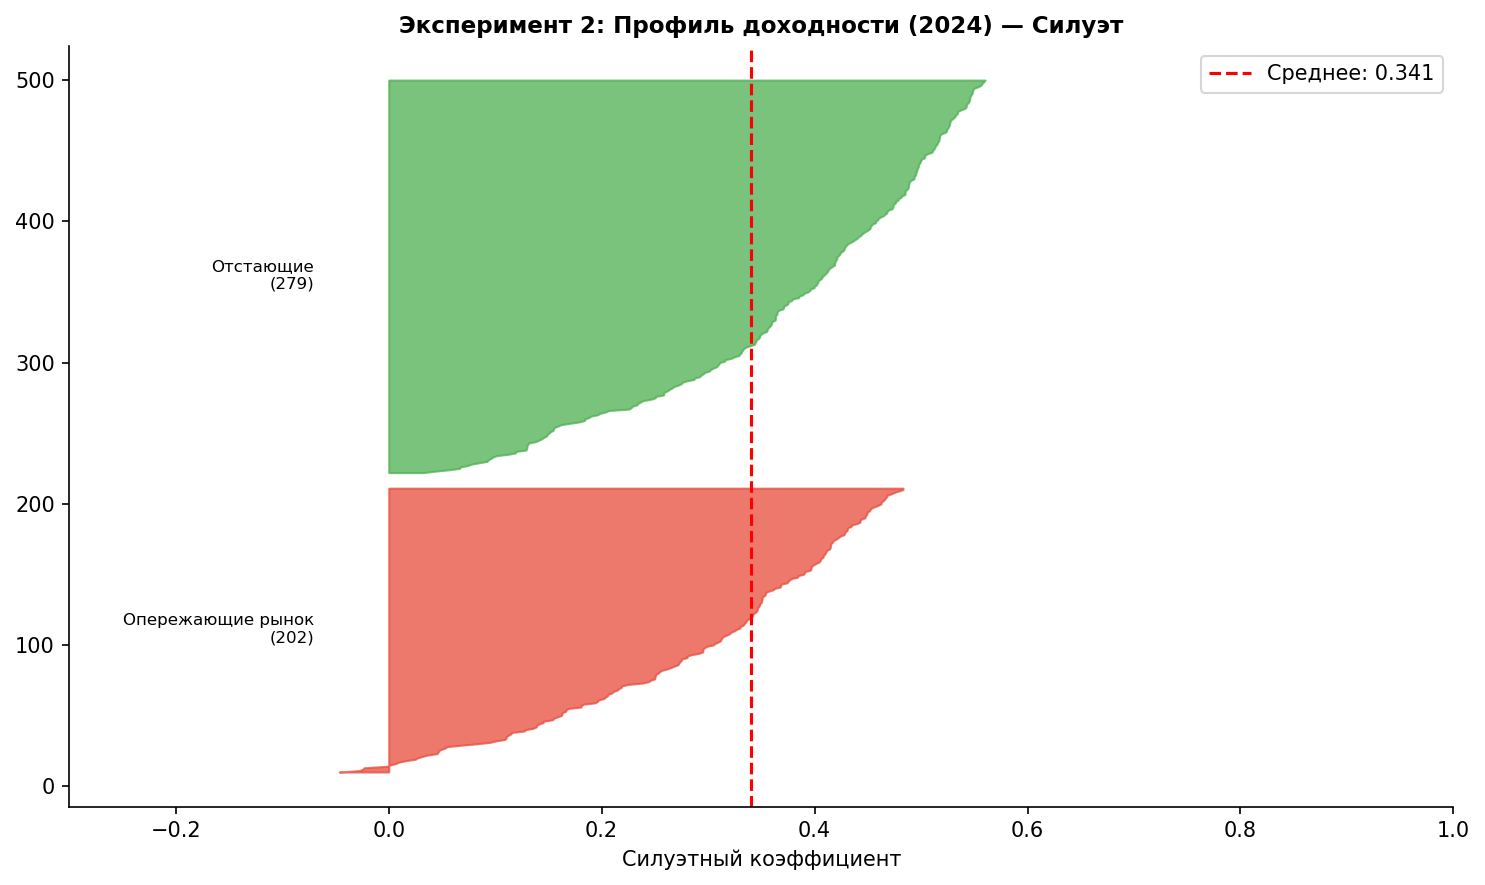

Silhouette: 0.341


In [83]:
sil_samples = silhouette_samples(X_scaled, labels_km)
sil_avg     = silhouette_score(X_scaled, labels_km)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(K_FINAL):
    cs      = np.sort(sil_samples[labels_km==i])
    y_upper = y_lower + len(cs)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cs,
                     alpha=0.75, color=CLUSTER_NAMES[i][1])
    ax.text(-0.07, y_lower+len(cs)/2,
            f'{CLUSTER_NAMES[i][0]}\n({len(cs)})',
            fontsize=8, ha='right', va='center')
    y_lower = y_upper + 10
ax.axvline(sil_avg, color='red', linestyle='--',
           label=f'Среднее: {sil_avg:.3f}')
ax.set_xlabel('Силуэтный коэффициент')
ax.set_title(f'{EXP_NAME} — Силуэт', fontsize=11, fontweight='bold')
ax.set_xlim(-0.3, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Silhouette: {sil_avg:.3f}")

## 14. Перекрёстный анализ Риск × Доходность

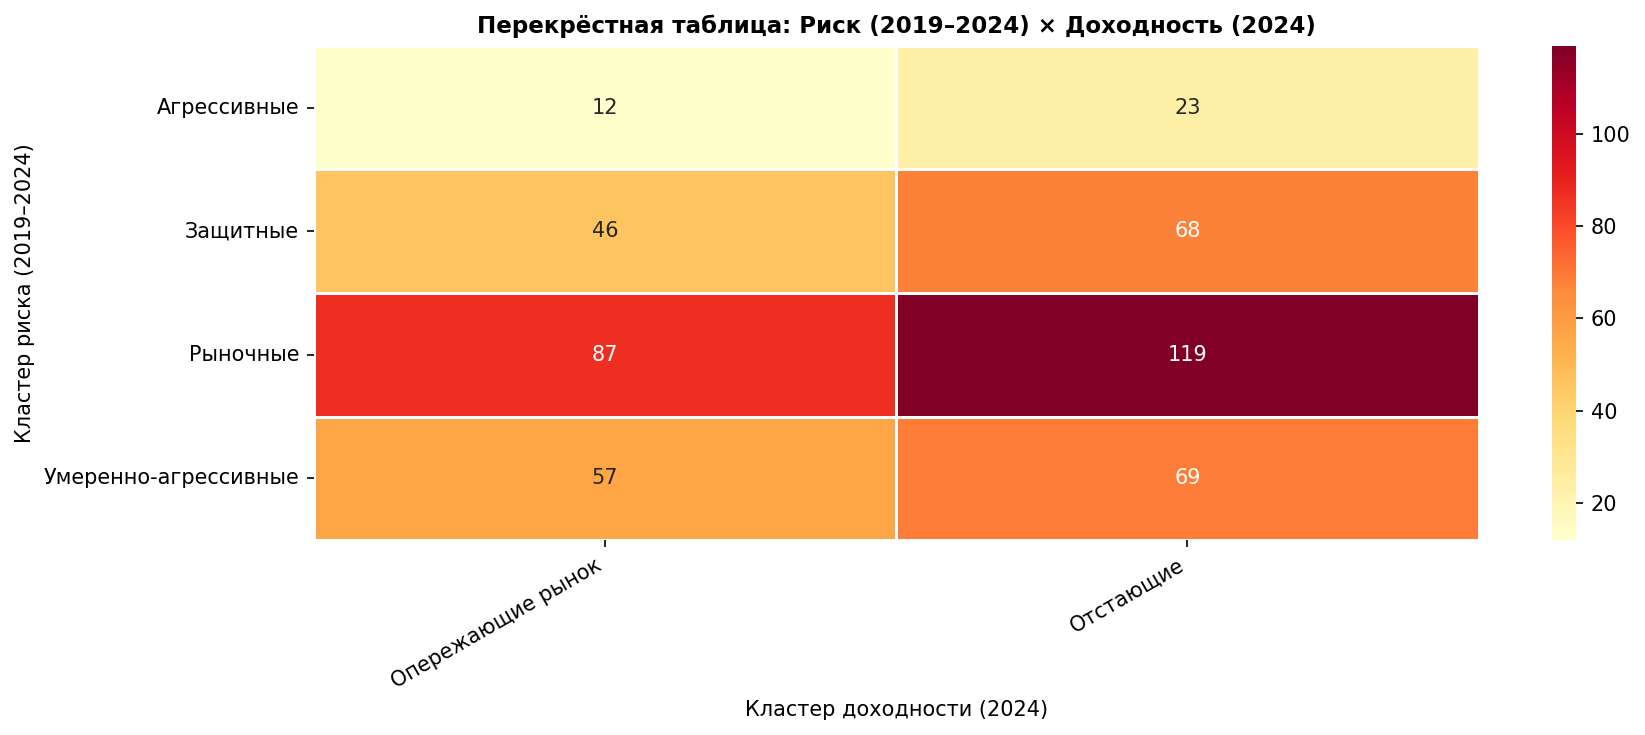

'Золотые' акции (Защитные × Лидеры импульса): 0


In [84]:
common_idx = X_raw.index.intersection(res_exp1.index)
cross_df   = pd.DataFrame({
    'risk_name'  : res_exp1.loc[common_idx, 'cluster_exp1_name'],
    'return_name': [
        CLUSTER_NAMES[c][0]
        for c in labels_km[
            X_raw.index.get_indexer(common_idx)
        ]
    ],
}, index=common_idx)

cross_tab = pd.crosstab(
    cross_df['risk_name'], cross_df['return_name']
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title(
    'Перекрёстная таблица: Риск (2019–2024) × Доходность (2024)',
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Кластер доходности (2024)')
ax.set_ylabel('Кластер риска (2019–2024)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_cross_risk_return.png',
            dpi=150, bbox_inches='tight')
plt.show()

# «Золотые» акции
BEST_RISK_CLUSTER   = 'Защитные'       # ← замени
BEST_RETURN_CLUSTER = 'Лидеры импульса' # ← замени

golden = cross_df[
    (cross_df['risk_name']   == BEST_RISK_CLUSTER) &
    (cross_df['return_name'] == BEST_RETURN_CLUSTER)
].index.tolist()

print(f"'Золотые' акции "
      f"({BEST_RISK_CLUSTER} × {BEST_RETURN_CLUSTER}): "
      f"{len(golden)}")
if golden:
    gdf = X_raw.loc[golden, FEATURES].round(3)
    gdf['sector'] = meta.loc[
        gdf.index.intersection(meta.index), 'sector'
    ]
    print(gdf.to_string())

## 15. Полный вывод компаний по кластерам

In [85]:
print("=" * 70)
print(f"  ПОЛНЫЙ СОСТАВ КЛАСТЕРОВ — {EXP_NAME}")
print("=" * 70)

for c_id, (c_name, c_color) in CLUSTER_NAMES.items():
    if c_id >= K_FINAL:
        continue
    mask    = X_result['cluster_km'] == c_id
    members = X_result[mask].sort_values('sharpe', ascending=False)

    print(f"\n{'─'*70}")
    print(f"  КЛАСТЕР {c_id}: {c_name.upper()} ({mask.sum()} акций)")
    print(f"  Шарп={members['sharpe'].mean():.3f} | "
          
          f"mom_12m={members['mom_12m'].mean():.3f} | "
          f"win_rate={members['win_rate'].mean():.3f}")
    print(f"{'─'*70}")

    show = members[FEATURES].copy()
    show['sector'] = meta.loc[
        show.index.intersection(meta.index), 'sector'
    ]
    show.index.name = 'Тикер'
    cols_rename = {**{c: LABELS[c] for c in FEATURES},
                   'sector': 'Сектор'}
    show.columns = [cols_rename.get(c, c) for c in show.columns]
    print(show.round(3).to_string())

    unc_mask = (X_result['cluster_km'] == c_id)
    core_pct = (uncertainty_idx[unc_mask.values] == 0).mean() * 100
    print(f"\n  Ядро: {core_pct:.0f}%")

    st_mask = stability_df['full_km'] == c_id
    if st_mask.sum() > 0:
        stab = stability_df.loc[st_mask,'stable'].mean()*100
        print(f"  Стабильность: {stab:.0f}%")

  ПОЛНЫЙ СОСТАВ КЛАСТЕРОВ — Эксперимент 2: Профиль доходности (2024)

──────────────────────────────────────────────────────────────────────
  КЛАСТЕР 0: ОПЕРЕЖАЮЩИЕ РЫНОК (202 акций)
  Шарп=1.326 | mom_12m=0.459 | win_rate=0.553
──────────────────────────────────────────────────────────────────────
       Коэф. Шарпа  Моментум 1М  Моментум 12М  Win Rate                  Сектор
Тикер                                                                          
TRGP         3.043       -0.117         1.105     0.610                  Energy
WMT          3.017       -0.012         0.745     0.586        Consumer Staples
IBKR         2.944       -0.063         1.165     0.606              Financials
GDDY         2.656        0.008         0.875     0.610  Information Technology
KMI          2.551       -0.025         0.637     0.542                  Energy
VST          2.519       -0.092         2.645     0.594               Utilities
FOX          2.497        0.039         0.692     0.582  Co

## 16. Итоговое сравнение алгоритмов и сохранение

In [86]:
ari_km_agg  = adjusted_rand_score(labels_km, labels_agg)
ari_km_gmm  = adjusted_rand_score(labels_km, labels_gmm)
ari_agg_gmm = adjusted_rand_score(labels_agg, labels_gmm)

rows = []
for algo, lbl, extra in [
    ('K-Means',        labels_km,  f'K={K_FINAL}'),
    ('Агломеративная', labels_agg, f'K={K_FINAL}, Ward'),
    ('GMM',            labels_gmm, f'K={K_FINAL}, BIC={gmm.bic(X_scaled):.0f}'),
]:
    rows.append({
        'Алгоритм'   : algo,
        'Параметры'  : extra,
        'Silhouette↑': round(silhouette_score(X_scaled, lbl), 3),
        'CH↑'        : round(calinski_harabasz_score(X_scaled, lbl), 1),
        'DB↓'        : round(davies_bouldin_score(X_scaled, lbl), 3),
    })

print(f"{'='*60}")
print(f"  Сравнение алгоритмов — {EXP_NAME}")
print(f"{'='*60}")
print(pd.DataFrame(rows).set_index('Алгоритм').to_string())
print(f"  ARI (KM vs Aggl): {ari_km_agg:.3f}")
print(f"  ARI (KM vs GMM):  {ari_km_gmm:.3f}")
print(f"  DBSCAN выбросов:  {n_noise}")
print(f"  Ядро кластеров:   {n_core} ({n_core/len(X_result)*100:.0f}%)")
print(f"  Стабильность:     {pct_stable:.0f}%")
print(f"{'='*60}")

# Сохранение
results = pd.DataFrame({
    'cluster_exp2_km'  : labels_km,
    'cluster_exp2_agg' : labels_agg,
    'cluster_exp2_gmm' : labels_gmm,
    'cluster_exp2_db'  : labels_db,
    'cluster_exp2_name': [CLUSTER_NAMES[c][0] for c in labels_km],
    'gmm_max_prob'     : max_proba,
    'uncertainty_idx'  : uncertainty_idx,
}, index=X_raw.index)
results.to_parquet('data/results_exp2.parquet')
stability_df.to_parquet('data/stability_exp2.parquet')

quality = {
    'experiment'     : 'Exp2_Return_1Y',
    'period'         : f'{MAIN_START} → {MAIN_END}',
    'features'       : str(FEATURES),
    'k_final'        : K_FINAL,
    'silhouette_km'  : round(silhouette_score(X_scaled, labels_km), 3),
    'silhouette_agg' : round(silhouette_score(X_scaled, labels_agg), 3),
    'silhouette_gmm' : round(silhouette_score(X_scaled, labels_gmm), 3),
    'silhouette_db'  : round(sil_db,3) if not np.isnan(sil_db) else None,
    'ari_km_agg'     : round(ari_km_agg, 3),
    'ari_km_gmm'     : round(ari_km_gmm, 3),
    'ari_agg_gmm'    : round(ari_agg_gmm, 3),
    'gmm_bic'        : round(gmm.bic(X_scaled), 1),
    'dbscan_noise'   : n_noise,
    'core_pct'       : round(n_core/len(X_result)*100, 1),
    'stability_pct'  : round(pct_stable, 1),
}
pd.DataFrame([quality]).to_csv('data/quality_exp2.csv', index=False)

print("\n✓ Сохранено:")
print("  data/results_exp2.parquet")
print("  data/stability_exp2.parquet")
print("  data/quality_exp2.csv")
print(f"  Следующий шаг: notebook_05_exp3_dynamics.ipynb")

  Сравнение алгоритмов — Эксперимент 2: Профиль доходности (2024)
                    Параметры  Silhouette↑    CH↑    DB↓
Алгоритм                                                
K-Means                   K=2        0.341  261.2  1.120
Агломеративная      K=2, Ward        0.319  243.5  1.157
GMM             K=2, BIC=3043        0.393   64.6  2.044
  ARI (KM vs Aggl): 0.694
  ARI (KM vs GMM):  0.080
  DBSCAN выбросов:  19
  Ядро кластеров:   277 (58%)
  Стабильность:     44%

✓ Сохранено:
  data/results_exp2.parquet
  data/stability_exp2.parquet
  data/quality_exp2.csv
  Следующий шаг: notebook_05_exp3_dynamics.ipynb
